In [2]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
GPU Name: NVIDIA RTX A4000


In [3]:
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# For: Mask2Former + Swin-Small

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Safer CUDA memory behavior
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

from transformers import Mask2FormerConfig, Mask2FormerForUniversalSegmentation

# --------------------------------------------------
# Cleanup and warning control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    """
    deterministic=False is recommended for the main training run:
    it keeps results reproducible enough while allowing faster CuDNN kernels.

    deterministic=True can be used for ablation/debug runs where exact repeatability
    is more important than speed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    """
    Ensures each dataloader worker has a reproducible but unique seed.
    Use later in DataLoader(worker_init_fn=seed_worker, generator=g).
    """
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Plotting setup
# --------------------------------------------------
%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device setup
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# TF32 can improve speed on Ampere+ GPUs with minimal practical impact for training
if torch.cuda.is_available():
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 enabled for faster matrix ops on supported GPUs.")
    except Exception:
        print("TF32 setup skipped.")

# --------------------------------------------------
# AMP setup
# --------------------------------------------------
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
print(f"Mixed Precision Enabled: {USE_AMP}")

# --------------------------------------------------
# Directory structure
# --------------------------------------------------
ROOT_DIR = Path(".")
CHECKPOINT_DIR = ROOT_DIR / "progressive_checkpoints_swinsmall"
PLOTS_DIR = ROOT_DIR / "training_plots_swinsmall"
LOGS_DIR = ROOT_DIR / "training_logs_swinsmall"
METRICS_DIR = ROOT_DIR / "training_metrics_swinsmall"

for d in [CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint directory ready at: {CHECKPOINT_DIR.resolve()}")
print(f"Plot directory ready at: {PLOTS_DIR.resolve()}")
print(f"Log directory ready at: {LOGS_DIR.resolve()}")
print(f"Metrics directory ready at: {METRICS_DIR.resolve()}")

# --------------------------------------------------
# Custom result export directories required later
# --------------------------------------------------
TRAIN_VIS_SAVE_DIR = Path("/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals")
FINAL_RESULTS_SAVE_DIR = Path("/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/Results_Export")

TRAIN_VIS_SAVE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_RESULTS_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Training visuals will be saved to: {TRAIN_VIS_SAVE_DIR}")
print(f"Final exported results will be saved to: {FINAL_RESULTS_SAVE_DIR}")

# --------------------------------------------------
# Model identity
# --------------------------------------------------
MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
MODEL_ALIAS = "Mask2Former + Swin-Small"

print(f"Planned model: {MODEL_ALIAS}")
print(f"Hugging Face model id: {MODEL_NAME}")

# --------------------------------------------------
# Runtime tracking containers
# --------------------------------------------------
history = {
    "epoch": [],
    "train_total_loss": [],
    "train_native_loss": [],
    "train_ce_loss": [],
    "train_lovasz_loss": [],
    "val_total_loss": [],
    "val_ce_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    "backbone_lr": [],
    "head_lr": [],
    "phase": [],
    "epoch_time_sec": []
}

best_record = {
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_macc": -1.0,
    "best_aacc": -1.0,
    "best_path": str(CHECKPOINT_DIR / "best_miou_checkpoint.pt")
}

print("Metric history containers initialized.")
print("Best-checkpoint tracking initialized.")

Seed set to 42 (deterministic=False for stable/efficient training)
Using Device: cuda
GPU: NVIDIA RTX A4000
CUDA Version: 12.1
Total GPU Memory: 15.73 GB
TF32 enabled for faster matrix ops on supported GPUs.
Mixed Precision Enabled: True
Checkpoint directory ready at: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/progressive_checkpoints_swinsmall
Plot directory ready at: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/training_plots_swinsmall
Log directory ready at: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/training_logs_swinsmall
Metrics directory ready at: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/training_metrics_swinsmall
Training visuals will be saved to: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals
Final exported results will be saved to: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/Results_Export
Planned model: Mask2Former + Swin-Small
Hugging Face model id: facebook/mask2former-swin-small-cityscapes-se

In [4]:
# ============================================================
# STEP 2: PATHS, HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# For: Mask2Former + Swin-Small
# Revised for stable training, better mIoU/mAcc, native validation,
# 600 dpi saves, and custom result directories
# ============================================================

from pathlib import Path
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# USER PATHS
# ------------------------------------------------------------
IMG_ROOT = "/home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/leftImg8bit_trainvaltest/leftImg8bit"
MASK_ROOT = "/home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/gtFine_trainvaltest/gtFine"

IMG_ROOT = Path(IMG_ROOT)
MASK_ROOT = Path(MASK_ROOT)

assert IMG_ROOT.exists(), f"IMG_ROOT not found: {IMG_ROOT}"
assert MASK_ROOT.exists(), f"MASK_ROOT not found: {MASK_ROOT}"

# ------------------------------------------------------------
# CUSTOM SAVE DIRECTORIES
# ------------------------------------------------------------
save_dir = "/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals"
FINAL_SAVE_DIR = "/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/Results_Export"

QUAL_VIS_DIR = Path(save_dir)
FINAL_SAVE_DIR = Path(FINAL_SAVE_DIR)

QUAL_VIS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Image root: {IMG_ROOT}")
print(f"Mask root : {MASK_ROOT}")
print(f"Training visualizations will be saved to: {QUAL_VIS_DIR.resolve()}")
print(f"Final exported results will be saved to: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")

# ------------------------------------------------------------
# CORE TASK SETTINGS
# ------------------------------------------------------------
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# IMAGE GEOMETRY
# ------------------------------------------------------------
# Keep Cityscapes-friendly rectangular crop
IMG_H = 512
IMG_W = 1024

# Native validation geometry
VAL_IMG_H = 1024
VAL_IMG_W = 2048

print(f"Train crop size      : {IMG_H} x {IMG_W}")
print(f"Validation image size: {VAL_IMG_H} x {VAL_IMG_W}")

# ------------------------------------------------------------
# BATCHING AND EPOCHS
# ------------------------------------------------------------
# Swin-Small is heavier than Swin-Tiny, so use safer per-step batch size.
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 8    # effective batch = 8
EPOCHS = 80

EARLY_STOPPING_PATIENCE = 12
MIN_EPOCHS_BEFORE_EARLY_STOP = 25
MIN_DELTA_MIOU = 0.001

print(f"Batch size           : {BATCH_SIZE}")
print(f"Grad accumulation    : {GRAD_ACCUM_STEPS}")
print(f"Effective batch size : {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Total epochs         : {EPOCHS}")

# ------------------------------------------------------------
# MODEL / TRAINING IDENTITY
# ------------------------------------------------------------
MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
MODEL_ALIAS = "Mask2Former + Swin-Small"

print(f"Model alias          : {MODEL_ALIAS}")
print(f"HF model id          : {MODEL_NAME}")

# ------------------------------------------------------------
# PROGRESSIVE UNFREEZING SCHEDULE
# ------------------------------------------------------------
# Keep this gentler than the earlier notebook.
# We avoid overly aggressive late full-unfreeze by default.
PHASE1_END_EPOCH = 20
PHASE2_END_EPOCH = 80
PHASE3_START_EPOCH = 81  # effectively disabled unless EPOCHS is increased later

PHASE1_HEAD_LR = 6e-5

PHASE2_BACKBONE_LR = 2e-6
PHASE2_HEAD_LR = 2e-5

PHASE3_BACKBONE_LR = 1e-6
PHASE3_HEAD_LR = 8e-6

WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0

# Recommended default: do not force full-unfreeze unless explicitly needed later
USE_FULL_UNFREEZE_PHASE = False
FREEZE_BATCHNORM_STATS = True

print("Progressive fine-tuning schedule configured:")
print(f"Phase 1: epochs 1 - {PHASE1_END_EPOCH}")
print(f"Phase 2: epochs {PHASE1_END_EPOCH + 1} - {PHASE2_END_EPOCH}")
print(f"Phase 3: epochs {PHASE3_START_EPOCH}+ (disabled by current EPOCHS={EPOCHS})")
print(f"Weight decay         : {WEIGHT_DECAY}")
print(f"Gradient clip norm   : {GRAD_CLIP_NORM}")
print(f"Use full unfreeze    : {USE_FULL_UNFREEZE_PHASE}")

# ------------------------------------------------------------
# SCHEDULER / LOSS SETTINGS
# ------------------------------------------------------------
WARMUP_STEPS = 2000
POLY_POWER = 0.9

USE_LOVASZ = True
LOVASZ_WEIGHT = 0.5
CE_WEIGHT = 1.0

# Optional later improvement hooks
USE_BOUNDARY_LOSS = True
BOUNDARY_LOSS_WEIGHT = 0.15

print(f"Warmup steps         : {WARMUP_STEPS}")
print(f"Poly power           : {POLY_POWER}")
print(f"CE weight            : {CE_WEIGHT}")
print(f"Lovasz enabled       : {USE_LOVASZ} (weight={LOVASZ_WEIGHT})")
print(f"Boundary loss enabled: {USE_BOUNDARY_LOSS} (weight={BOUNDARY_LOSS_WEIGHT})")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
USE_SLIDING_WINDOW_VAL = True
VAL_WINDOW_SIZE = (512, 1024)
VAL_WINDOW_STRIDE = (341, 682)   # overlap for smoother stitching

# Final evaluation switches
USE_FLIP_TTA = True
USE_MULTI_SCALE_VAL = False      # keep False during training for speed
MULTI_SCALE_FACTORS = [0.75, 1.0, 1.25, 1.5]

print(f"Sliding-window validation: {USE_SLIDING_WINDOW_VAL}")
if USE_SLIDING_WINDOW_VAL:
    print(f"Window size             : {VAL_WINDOW_SIZE}")
    print(f"Window stride           : {VAL_WINDOW_STRIDE}")
print(f"Flip TTA                : {USE_FLIP_TTA}")
print(f"Multi-scale eval        : {USE_MULTI_SCALE_VAL}")
print(f"Multi-scale factors     : {MULTI_SCALE_FACTORS}")

# ------------------------------------------------------------
# RARE / HARD CLASS SETTINGS
# ------------------------------------------------------------
# Used later for rare-class-aware sampling or analysis if needed.
RARE_CLASS_IDS = [3, 4, 5, 6, 7, 9, 12, 17, 18]  # wall, fence, pole, tlight, tsign, terrain, rider, motorcycle, bicycle
RARE_CLASS_NAMES = [CLASS_NAMES[i] for i in RARE_CLASS_IDS]
USE_RARE_CLASS_AWARE_SAMPLING = True

print(f"Rare-class-aware sampling enabled: {USE_RARE_CLASS_AWARE_SAMPLING}")
print(f"Rare/hard classes: {RARE_CLASS_NAMES}")

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

# ------------------------------------------------------------
# LABEL ENCODING / DECODING
# ------------------------------------------------------------
def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)

    # already in trainIds?
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)

    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color

    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# SANITY CHECK HELPERS
# ------------------------------------------------------------
def print_mask_stats(mask: np.ndarray, name: str = "mask"):
    uniq, counts = np.unique(mask, return_counts=True)
    stats = dict(zip(uniq.tolist(), counts.tolist()))
    print(f"{name} unique labels: {sorted(stats.keys())}")
    print(f"{name} counts       : {stats}")

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)

    model.eval()

    batch = next(iter(loader))
    images, mask_labels, class_labels = batch
    images = images.to(DEVICE)

    _, _, current_h, current_w = images.shape

    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            outputs = model(pixel_values=images)

            mask_preds = F.interpolate(
                outputs.masks_queries_logits,
                size=(current_h, current_w),
                mode="bilinear",
                align_corners=False
            )

            mask_cls = outputs.class_queries_logits.softmax(dim=-1)[..., :-1]
            semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())
            preds = torch.argmax(semantic_logits, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets = np.full((len(images_np), current_h, current_w), IGNORE_INDEX, dtype=np.uint8)

    for batch_idx in range(len(class_labels)):
        for inst_idx, class_id in enumerate(class_labels[batch_idx]):
            cls_id = int(class_id.item())
            if cls_id != IGNORE_INDEX and 0 <= cls_id < CLASSES:
                instance_mask = mask_labels[batch_idx][inst_idx].cpu().numpy() == 1
                targets[batch_idx][instance_mask] = cls_id

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"Prediction (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved qualitative comparison: {out_file}")

# ------------------------------------------------------------
# SAVE VISUALS EVERY 10 EPOCHS
# ------------------------------------------------------------
def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    """
    Call this inside the Step 5 training loop.
    Saves visuals only at epochs divisible by 10.
    """
    if epoch % 10 == 0:
        visualize_results(
            loader=loader,
            model=model,
            epoch=epoch,
            save_path=save_path,
            max_images=max_images
        )

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
train_imgs = sorted(glob.glob(str(IMG_ROOT / "train" / "*" / "*_leftImg8bit.png")))
val_imgs = sorted(glob.glob(str(IMG_ROOT / "val" / "*" / "*_leftImg8bit.png")))

train_masks = sorted(glob.glob(str(MASK_ROOT / "train" / "*" / "*_gtFine_labelIds.png")))
val_masks = sorted(glob.glob(str(MASK_ROOT / "val" / "*" / "*_gtFine_labelIds.png")))

print(f"Found {len(train_imgs)} training images")
print(f"Found {len(val_imgs)} validation images")
print(f"Found {len(train_masks)} training masks")
print(f"Found {len(val_masks)} validation masks")

assert len(train_imgs) == len(train_masks), "Training image/mask count mismatch"
assert len(val_imgs) == len(val_masks), "Validation image/mask count mismatch"

print("Step 2 ready")

Image root: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/leftImg8bit_trainvaltest/leftImg8bit
Mask root : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/gtFine_trainvaltest/gtFine
Training visualizations will be saved to: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals
Final exported results will be saved to: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/Results_Export
DEVICE: cuda
Train crop size      : 512 x 1024
Validation image size: 1024 x 2048
Batch size           : 1
Grad accumulation    : 8
Effective batch size : 8
Total epochs         : 80
Model alias          : Mask2Former + Swin-Small
HF model id          : facebook/mask2former-swin-small-cityscapes-semantic
Progressive fine-tuning schedule configured:
Phase 1: epochs 1 - 20
Phase 2: epochs 21 - 80
Phase 3: epochs 81+ (disabled by current EPOCHS=80)
Weight decay         : 0.01
Gradient clip norm   : 1.0
Use full unfreeze    : False
Warmup steps         : 

In [5]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS
# For: Mask2Former + Swin-Small
# Revised for stable training, honest validation, improved mIoU,
# and rare-class-aware crop sampling
# ============================================================

import inspect

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class CityscapesDataset(Dataset):
    def __init__(self, img_root, mask_root, split="train", transform=None, rare_class_ids=None, rare_retry_count=0):
        self.transform = transform
        self.split = split
        self.rare_class_ids = rare_class_ids if rare_class_ids is not None else []
        self.rare_retry_count = rare_retry_count

        self.img_dir = Path(img_root) / split
        self.mask_dir = Path(mask_root) / split

        self.images = sorted(self.img_dir.glob("*/*_leftImg8bit.png"))
        if len(self.images) == 0:
            raise FileNotFoundError(f"No images found in: {self.img_dir}")

        self.masks = []
        for img_path in self.images:
            city = img_path.parent.name
            filename = img_path.name

            if USE_LABEL_TRAINIDS:
                mask_filename = filename.replace("_leftImg8bit.png", "_gtFine_labelTrainIds.png")
            else:
                mask_filename = filename.replace("_leftImg8bit.png", "_gtFine_labelIds.png")

            mask_path = self.mask_dir / city / mask_filename

            # fallback to labelIds if labelTrainIds file does not exist
            if USE_LABEL_TRAINIDS and (not mask_path.exists()):
                mask_path = Path(str(mask_path).replace("_gtFine_labelTrainIds.png", "_gtFine_labelIds.png"))

            self.masks.append(mask_path)

        missing = [str(m) for m in self.masks if not m.exists()]
        if len(missing) > 0:
            raise FileNotFoundError(
                f"Missing {len(missing)} masks. Example missing file:\n{missing[0]}"
            )

        assert len(self.images) == len(self.masks), "Image/mask length mismatch"

        print(f"[{split}] Found {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def _load_raw(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"cv2.imread failed for image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"cv2.imread failed for mask: {mask_path}")

        mask = encode_mask(mask)  # {0..18, 255}
        return image, mask

    def _contains_rare_class(self, mask):
        if len(self.rare_class_ids) == 0:
            return False
        unique_ids = np.unique(mask)
        return any(int(cls_id) in unique_ids for cls_id in self.rare_class_ids)

    def __getitem__(self, idx):
        image, mask = self._load_raw(idx)

        # --------------------------------------------------
        # Rare-class-aware crop retry for training only
        # --------------------------------------------------
        # Idea:
        # Try augmentation multiple times and prefer a crop containing rare/hard classes.
        # This helps classes like pole, traffic light, rider, motorcycle, etc.
        if self.transform is not None:
            if self.split == "train" and self.rare_retry_count > 0:
                selected_aug = None

                for attempt in range(self.rare_retry_count):
                    augmented = self.transform(image=image, mask=mask)
                    aug_mask = augmented["mask"]

                    # ToTensorV2 may already convert to tensor
                    if torch.is_tensor(aug_mask):
                        aug_mask_np = aug_mask.cpu().numpy()
                    else:
                        aug_mask_np = aug_mask

                    if self._contains_rare_class(aug_mask_np):
                        selected_aug = augmented
                        break

                    # keep last attempt as fallback
                    selected_aug = augmented

                augmented = selected_aug
            else:
                augmented = self.transform(image=image, mask=mask)

            image = augmented["image"]
            mask = augmented["mask"]

        # image -> tensor float, mask -> tensor long
        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()

        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        # --------------------------------------------------
        # Build Mask2Former targets
        # --------------------------------------------------
        unique_labels = torch.unique(mask)
        unique_labels = unique_labels[unique_labels != IGNORE_INDEX]

        if unique_labels.numel() == 0:
            class_labels = torch.empty((0,), dtype=torch.long)
            mask_labels = torch.empty((0, mask.shape[0], mask.shape[1]), dtype=torch.float32)
        else:
            class_labels = unique_labels.long()
            mask_labels = (mask.unsqueeze(0) == class_labels[:, None, None]).float()

        return image, mask_labels, class_labels


# ------------------------------------------------------------
# AUGMENTATION HELPERS
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    """
    Albumentations changed parameter names across versions.
    This helper keeps the code compatible.
    """
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(
        min_height=min_h,
        min_width=min_w,
        border_mode=cv2.BORDER_CONSTANT,
        p=1.0
    )

    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)

    return A.PadIfNeeded(**kwargs)


# ------------------------------------------------------------
# TRAINING TRANSFORMS
# ------------------------------------------------------------
# Design choices:
# - keep Cityscapes geometry with 512x1024 crop
# - random scaling for multi-scale robustness
# - mild blur and mild color jitter
# - no validation resize
train_transform = A.Compose([
    A.RandomScale(scale_limit=(-0.5, 1.0), interpolation=cv2.INTER_LINEAR, p=1.0),  # ~0.5x to 2.0x
    pad_if_needed_tf(IMG_H, IMG_W, IGNORE_INDEX),
    A.RandomCrop(height=IMG_H, width=IMG_W, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
        p=0.3
    ),
    A.GaussianBlur(blur_limit=(3, 3), p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# VALIDATION TRANSFORMS
# ------------------------------------------------------------
# Keep native geometry and do not resize.
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])


# ------------------------------------------------------------
# COLLATE FUNCTION FOR MASK2FORMER
# ------------------------------------------------------------
def mask2former_collate_fn(batch):
    """
    Returns:
        images:       (B, C, H, W)
        mask_labels:  list[(Ki, H, W)]
        class_labels: list[(Ki,)]
    """
    images = torch.stack([item[0] for item in batch], dim=0)
    mask_labels = [item[1] for item in batch]
    class_labels = [item[2] for item in batch]
    return images, mask_labels, class_labels


# ------------------------------------------------------------
# DATASETS
# ------------------------------------------------------------
rare_retry_count = 4 if USE_RARE_CLASS_AWARE_SAMPLING else 0

train_dataset = CityscapesDataset(
    img_root=IMG_ROOT,
    mask_root=MASK_ROOT,
    split="train",
    transform=train_transform,
    rare_class_ids=RARE_CLASS_IDS,
    rare_retry_count=rare_retry_count
)

val_dataset = CityscapesDataset(
    img_root=IMG_ROOT,
    mask_root=MASK_ROOT,
    split="val",
    transform=val_transform,
    rare_class_ids=None,
    rare_retry_count=0
)

# ------------------------------------------------------------
# DATALOADER SETTINGS
# ------------------------------------------------------------
# Swin-Small is heavier than Swin-Tiny, so keep this conservative.
NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

print(f"Num workers         : {NUM_WORKERS}")
print(f"Pin memory          : {PIN_MEMORY}")
print(f"Persistent workers  : {PERSISTENT_WORKERS}")
print(f"Rare retry count    : {rare_retry_count}")

# Train loader:
# - shuffle enabled
# - drop_last=True for more stable gradient accumulation
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# Validation loader:
# - batch_size=1 for native 1024x2048 validation
# - shuffle disabled for reproducibility
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

print(f"DataLoaders ready: {len(train_dataset)} train images, {len(val_dataset)} val images")

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
# Train batch sanity
train_batch = next(iter(train_loader))
train_images, train_mask_labels, train_class_labels = train_batch

print("\nTrain batch sanity check")
print(f"images shape              : {train_images.shape}")
print(f"sample0 num segments      : {train_mask_labels[0].shape[0]}")
print(f"sample0 mask tensor shape : {train_mask_labels[0].shape}")
print(f"sample0 class labels      : {train_class_labels[0].tolist()[:10]}{' ...' if len(train_class_labels[0]) > 10 else ''}")

# Validation batch sanity
val_batch = next(iter(val_loader))
val_images, val_mask_labels, val_class_labels = val_batch

print("\nValidation batch sanity check")
print(f"images shape              : {val_images.shape}")
print(f"sample0 num segments      : {val_mask_labels[0].shape[0]}")
print(f"sample0 mask tensor shape : {val_mask_labels[0].shape}")
print(f"sample0 class labels      : {val_class_labels[0].tolist()[:10]}{' ...' if len(val_class_labels[0]) > 10 else ''}")

# Final assertions
assert train_images.shape[-2:] == (IMG_H, IMG_W), "Training images are not at the expected crop size"
assert val_images.shape[-2:] == (VAL_IMG_H, VAL_IMG_W), "Validation images are not at native resolution"

print("\nStep 3 ready")

[train] Found 2975 images
[val] Found 500 images
Num workers         : 4
Pin memory          : True
Persistent workers  : True
Rare retry count    : 4
DataLoaders ready: 2975 train images, 500 val images

Train batch sanity check
images shape              : torch.Size([1, 3, 512, 1024])
sample0 num segments      : 11
sample0 mask tensor shape : torch.Size([11, 512, 1024])
sample0 class labels      : [0, 1, 2, 4, 5, 6, 7, 8, 11, 13] ...

Validation batch sanity check
images shape              : torch.Size([1, 3, 1024, 2048])
sample0 num segments      : 10
sample0 mask tensor shape : torch.Size([10, 1024, 2048])
sample0 class labels      : [0, 1, 2, 4, 5, 7, 8, 10, 11, 13]

Step 3 ready


In [6]:
# ============================================================
# STEP 4: MODEL, PHASE MANAGEMENT, LOSS, OPTIMIZER, SCHEDULER
# For: Mask2Former + Swin-Small
# Revised for stable fine-tuning, reduced overfitting, better mIoU/mAcc,
# clean HF loading, and optional boundary-aware supervision
# ============================================================

import os
import math
import warnings
import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
from transformers import Mask2FormerForUniversalSegmentation

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
if "train_loader" not in globals():
    raise NameError("train_loader is not defined. Please run Step 3 first.")

if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "CLASSES" not in globals():
    CLASSES = 19

if "CLASS_NAMES" not in globals():
    CLASS_NAMES = [
        "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
        "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
        "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
    ]

if "IGNORE_INDEX" not in globals():
    IGNORE_INDEX = 255

# ------------------------------------------------------------
# HYPERPARAMETERS FROM STEP 2
# ------------------------------------------------------------
WEIGHT_DECAY = globals().get("WEIGHT_DECAY", 0.01)
GRAD_CLIP_NORM = globals().get("GRAD_CLIP_NORM", 1.0)

PHASE1_END_EPOCH = globals().get("PHASE1_END_EPOCH", 20)
PHASE2_END_EPOCH = globals().get("PHASE2_END_EPOCH", 80)
PHASE3_START_EPOCH = globals().get("PHASE3_START_EPOCH", 81)

PHASE1_HEAD_LR = globals().get("PHASE1_HEAD_LR", 6e-5)
PHASE2_BACKBONE_LR = globals().get("PHASE2_BACKBONE_LR", 2e-6)
PHASE2_HEAD_LR = globals().get("PHASE2_HEAD_LR", 2e-5)
PHASE3_BACKBONE_LR = globals().get("PHASE3_BACKBONE_LR", 1e-6)
PHASE3_HEAD_LR = globals().get("PHASE3_HEAD_LR", 8e-6)

WARMUP_STEPS = globals().get("WARMUP_STEPS", 2000)
POLY_POWER = globals().get("POLY_POWER", 0.9)

USE_LOVASZ = globals().get("USE_LOVASZ", True)
LOVASZ_WEIGHT = globals().get("LOVASZ_WEIGHT", 0.5)
CE_WEIGHT = globals().get("CE_WEIGHT", 1.0)

USE_BOUNDARY_LOSS = globals().get("USE_BOUNDARY_LOSS", True)
BOUNDARY_LOSS_WEIGHT = globals().get("BOUNDARY_LOSS_WEIGHT", 0.15)

FREEZE_BATCHNORM_STATS = globals().get("FREEZE_BATCHNORM_STATS", True)
USE_FULL_UNFREEZE_PHASE = globals().get("USE_FULL_UNFREEZE_PHASE", False)

USE_AMP = globals().get("USE_AMP", torch.cuda.is_available())
scaler = globals().get(
    "scaler",
    torch.amp.GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
)

if "GRAD_ACCUM_STEPS" not in globals():
    GRAD_ACCUM_STEPS = 1
if "EPOCHS" not in globals():
    EPOCHS = 80

# ------------------------------------------------------------
# LABEL MAPS
# ------------------------------------------------------------
id2label = {i: CLASS_NAMES[i] for i in range(CLASSES)}
label2id = {v: k for k, v in id2label.items()}

# ------------------------------------------------------------
# HF TOKEN SETUP
# ------------------------------------------------------------
HF_TOKEN = os.environ.get("HF_TOKEN", None)

if HF_TOKEN is None:
    warnings.filterwarnings(
        "ignore",
        message=".*unauthenticated requests to the HF Hub.*"
    )

# ------------------------------------------------------------
# LOAD PRETRAINED MODEL
# ------------------------------------------------------------
MODEL_NAME = globals().get("MODEL_NAME", "facebook/mask2former-swin-small-cityscapes-semantic")
MODEL_ALIAS = globals().get("MODEL_ALIAS", "Mask2Former + Swin-Small")

load_kwargs = dict(
    pretrained_model_name_or_path=MODEL_NAME,
    num_labels=CLASSES,
    ignore_mismatched_sizes=True,
    id2label=id2label,
    label2id=label2id,
)

if HF_TOKEN is not None:
    load_kwargs["token"] = HF_TOKEN

model = Mask2FormerForUniversalSegmentation.from_pretrained(**load_kwargs).to(DEVICE)

print(f"Loaded model: {MODEL_NAME}")
print(f"Model alias : {MODEL_ALIAS}")
if HF_TOKEN is not None:
    print("HF_TOKEN detected: authenticated Hugging Face access enabled.")
else:
    print("No HF_TOKEN found: using public access mode.")

# ------------------------------------------------------------
# OPTIONAL: FREEZE BATCHNORM / NORM STATS FOR STABILITY
# ------------------------------------------------------------
def freeze_norm_layers(module: torch.nn.Module):
    norm_types = (
        torch.nn.BatchNorm1d,
        torch.nn.BatchNorm2d,
        torch.nn.BatchNorm3d,
        torch.nn.SyncBatchNorm
    )
    for m in module.modules():
        if isinstance(m, norm_types):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False

if FREEZE_BATCHNORM_STATS:
    freeze_norm_layers(model)
    print("BatchNorm-like layers frozen for stability (if present).")

# ------------------------------------------------------------
# LOVASZ-SOFTMAX LOSS
# ------------------------------------------------------------
def lovasz_grad(gt_sorted: torch.Tensor) -> torch.Tensor:
    p = len(gt_sorted)
    gts = gt_sorted.sum()

    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / (union + 1e-10)

    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]

    return jaccard

def _safe_mean(losses, device):
    if len(losses) == 0:
        return torch.tensor(0.0, device=device, requires_grad=True)
    return sum(losses) / len(losses)

def lovasz_softmax_flat(probs: torch.Tensor, labels: torch.Tensor, classes="present") -> torch.Tensor:
    if probs.numel() == 0:
        return torch.tensor(0.0, device=probs.device, requires_grad=True)

    C = probs.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ["all", "present"] else classes

    for c in class_to_sum:
        fg = (labels == c).float()
        if classes == "present" and fg.sum() == 0:
            continue

        class_pred = probs[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, descending=True)
        fg_sorted = fg[perm]

        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))

    return _safe_mean(losses, probs.device)

def lovasz_softmax_from_logits(logits: torch.Tensor, labels: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    probs = F.softmax(logits, dim=1)
    valid_mask = (labels != ignore_index)

    if valid_mask.sum() == 0:
        return torch.tensor(0.0, device=logits.device, requires_grad=True)

    probs_valid = probs.permute(0, 2, 3, 1)[valid_mask]
    labels_valid = labels[valid_mask]

    return lovasz_softmax_flat(probs_valid, labels_valid, classes="present")

# ------------------------------------------------------------
# BOUNDARY LOSS HELPERS
# ------------------------------------------------------------
def compute_boundary_map(targets: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    """
    targets: [B, H, W]
    returns: boundary map [B, H, W] float
    """
    B, H, W = targets.shape
    boundary = torch.zeros_like(targets, dtype=torch.float32)

    valid = (targets != ignore_index)

    # horizontal boundary
    boundary[:, :, 1:] |= ((targets[:, :, 1:] != targets[:, :, :-1]) & valid[:, :, 1:] & valid[:, :, :-1])
    # vertical boundary
    boundary[:, 1:, :] |= ((targets[:, 1:, :] != targets[:, :-1, :]) & valid[:, 1:, :] & valid[:, :-1, :])

    return boundary.float()

def compute_boundary_loss(semantic_logits: torch.Tensor, dense_targets: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    """
    Simple boundary-aware auxiliary loss.
    """
    with torch.no_grad():
        target_boundary = compute_boundary_map(dense_targets, ignore_index=ignore_index)

    probs = F.softmax(semantic_logits, dim=1)
    pred_labels = torch.argmax(probs, dim=1)
    pred_boundary = compute_boundary_map(pred_labels, ignore_index=ignore_index)

    # Compare soft boundary target to predicted hard boundary map
    return F.binary_cross_entropy(pred_boundary.clamp(0, 1), target_boundary)

# ------------------------------------------------------------
# INSTANCE TARGETS -> DENSE SEMANTIC TARGET MAP
# ------------------------------------------------------------
def build_semantic_targets_from_instance_targets(mask_labels, class_labels, image_size, ignore_index=255):
    H, W = image_size
    batch_size = len(mask_labels)

    device = mask_labels[0].device if len(mask_labels) > 0 else DEVICE
    targets = torch.full(
        (batch_size, H, W),
        fill_value=ignore_index,
        dtype=torch.long,
        device=device
    )

    for b in range(batch_size):
        if class_labels[b].numel() == 0:
            continue

        for inst_idx, cls_id in enumerate(class_labels[b]):
            cls_id = int(cls_id.item())
            if cls_id == ignore_index:
                continue
            targets[b][mask_labels[b][inst_idx] > 0.5] = cls_id

    return targets

# ------------------------------------------------------------
# HYBRID LOSS
# ------------------------------------------------------------
def compute_hybrid_loss(
    outputs,
    dense_targets,
    ce_weight=1.0,
    lovasz_weight=0.5,
    use_lovasz=True,
    use_boundary_loss=False,
    boundary_loss_weight=0.15
):
    native_loss = outputs.loss if outputs.loss is not None else torch.tensor(0.0, device=dense_targets.device)

    mask_preds = outputs.masks_queries_logits
    class_logits = outputs.class_queries_logits

    H, W = dense_targets.shape[1], dense_targets.shape[2]

    mask_preds_up = F.interpolate(
        mask_preds,
        size=(H, W),
        mode="bilinear",
        align_corners=False
    )

    mask_cls = F.softmax(class_logits, dim=-1)[..., :-1]
    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())

    ce_loss = F.cross_entropy(
        semantic_logits,
        dense_targets,
        ignore_index=IGNORE_INDEX
    )

    if use_lovasz:
        lovasz_loss = lovasz_softmax_from_logits(
            semantic_logits,
            dense_targets,
            ignore_index=IGNORE_INDEX
        )
    else:
        lovasz_loss = torch.tensor(0.0, device=dense_targets.device)

    if use_boundary_loss:
        boundary_loss = compute_boundary_loss(
            semantic_logits,
            dense_targets,
            ignore_index=IGNORE_INDEX
        )
    else:
        boundary_loss = torch.tensor(0.0, device=dense_targets.device)

    total_loss = (
        native_loss
        + (ce_weight * ce_loss)
        + (lovasz_weight * lovasz_loss)
        + (boundary_loss_weight * boundary_loss)
    )

    loss_dict = {
        "native_loss": float(native_loss.detach().item()),
        "ce_loss": float(ce_loss.detach().item()),
        "lovasz_loss": float(lovasz_loss.detach().item()),
        "boundary_loss": float(boundary_loss.detach().item()),
        "total_loss": float(total_loss.detach().item())
    }

    return total_loss, loss_dict, semantic_logits

# ------------------------------------------------------------
# PHASE MANAGEMENT
# ------------------------------------------------------------
def get_current_phase(epoch: int) -> int:
    if epoch <= PHASE1_END_EPOCH:
        return 1
    elif epoch <= PHASE2_END_EPOCH:
        return 2
    else:
        return 3

def _set_requires_grad_by_name(model, allow_fn):
    for name, param in model.named_parameters():
        param.requires_grad = allow_fn(name)

def set_model_phase(model, phase: int, use_full_unfreeze_phase: bool = False):
    """
    Safer progressive fine-tuning for Swin-Small:

    Phase 1:
        Train decoder/head only, keep pixel-level module frozen.
    Phase 2:
        Unfreeze only later encoder layers plus decoder/head.
    Phase 3:
        Optional full fine-tune, disabled by default.
    """
    for p in model.parameters():
        p.requires_grad = False

    if phase == 1:
        print("PHASE 1: Head/decoder adaptation only")

        def allow_fn(name):
            return "pixel_level_module" not in name

        _set_requires_grad_by_name(model, allow_fn)

    elif phase == 2:
        print("PHASE 2: Partial unfreeze")

        def allow_fn(name):
            if "pixel_level_module.encoder" in name:
                return (
                    ("layers.2" in name) or
                    ("layers.3" in name) or
                    ("layernorm" in name.lower()) or
                    ("norm" in name.lower())
                )
            return True

        _set_requires_grad_by_name(model, allow_fn)

    elif phase == 3:
        if use_full_unfreeze_phase:
            print("PHASE 3: Gentle full fine-tune")
            for p in model.parameters():
                p.requires_grad = True
        else:
            print("PHASE 3 skipped: keeping Phase 2 trainable set")
            set_model_phase(model, phase=2, use_full_unfreeze_phase=use_full_unfreeze_phase)
            return

    else:
        raise ValueError(f"Unknown phase: {phase}")

    if FREEZE_BATCHNORM_STATS:
        freeze_norm_layers(model)

def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# ------------------------------------------------------------
# PARAMETER GROUPING
# ------------------------------------------------------------
def is_backbone_param(name: str) -> bool:
    return "pixel_level_module.encoder" in name

def get_optimizer_for_phase(model, phase: int):
    if phase == 1:
        head_params = [p for n, p in model.named_parameters() if p.requires_grad]

        optimizer = optim.AdamW(
            [{"params": head_params, "lr": PHASE1_HEAD_LR}],
            weight_decay=WEIGHT_DECAY,
            betas=(0.9, 0.999),
            eps=1e-8
        )
        return optimizer

    elif phase == 2:
        backbone_params = []
        head_params = []

        for n, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if is_backbone_param(n):
                backbone_params.append(p)
            else:
                head_params.append(p)

        param_groups = []
        if len(backbone_params) > 0:
            param_groups.append({"params": backbone_params, "lr": PHASE2_BACKBONE_LR})
        if len(head_params) > 0:
            param_groups.append({"params": head_params, "lr": PHASE2_HEAD_LR})

        optimizer = optim.AdamW(
            param_groups,
            weight_decay=WEIGHT_DECAY,
            betas=(0.9, 0.999),
            eps=1e-8
        )
        return optimizer

    elif phase == 3:
        backbone_params = []
        head_params = []

        for n, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if is_backbone_param(n):
                backbone_params.append(p)
            else:
                head_params.append(p)

        param_groups = []
        if len(backbone_params) > 0:
            param_groups.append({"params": backbone_params, "lr": PHASE3_BACKBONE_LR})
        if len(head_params) > 0:
            param_groups.append({"params": head_params, "lr": PHASE3_HEAD_LR})

        optimizer = optim.AdamW(
            param_groups,
            weight_decay=WEIGHT_DECAY,
            betas=(0.9, 0.999),
            eps=1e-8
        )
        return optimizer

    else:
        raise ValueError(f"Unknown phase: {phase}")

# ------------------------------------------------------------
# POLY LR SCHEDULER WITH WARMUP
# ------------------------------------------------------------
def build_poly_scheduler(optimizer, total_update_steps, warmup_steps=2000, power=0.9):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))

        progress = float(current_step - warmup_steps) / float(max(1, total_update_steps - warmup_steps))
        progress = min(max(progress, 0.0), 1.0)
        return (1.0 - progress) ** power

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------
def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp

    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)

    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)

    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)

    return {
        "mIoU": float(mIoU),
        "aAcc": float(aAcc),
        "mAcc": float(mAcc),
        "iou_per_class": iou_per_class,
        "acc_per_class": acc_per_class
    }

# ------------------------------------------------------------
# INITIALIZE FOR PHASE 1
# ------------------------------------------------------------
current_phase = 1
set_model_phase(model, phase=current_phase, use_full_unfreeze_phase=USE_FULL_UNFREEZE_PHASE)

total_params, trainable_params = count_trainable_params(model)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

optimizer = get_optimizer_for_phase(model, current_phase)

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
total_update_steps = steps_per_epoch * EPOCHS

scheduler = build_poly_scheduler(
    optimizer=optimizer,
    total_update_steps=total_update_steps,
    warmup_steps=WARMUP_STEPS,
    power=POLY_POWER
)

print("Phase 1 optimizer initialized.")
print(f"Weight decay         : {WEIGHT_DECAY}")
print(f"AMP enabled          : {scaler.is_enabled()}")
print(f"Steps/epoch          : {steps_per_epoch}")
print(f"Total update steps   : {total_update_steps}")
print(f"Warmup steps         : {WARMUP_STEPS}")
print(f"Poly scheduler power : {POLY_POWER}")
print(f"Boundary loss        : {USE_BOUNDARY_LOSS} (weight={BOUNDARY_LOSS_WEIGHT})")
print("Step 4 ready")

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Loaded model: facebook/mask2former-swin-small-cityscapes-semantic
Model alias : Mask2Former + Swin-Small
No HF_TOKEN found: using public access mode.
BatchNorm-like layers frozen for stability (if present).
PHASE 1: Head/decoder adaptation only
Total parameters     : 68,723,870
Trainable parameters : 14,463,764
Phase 1 optimizer initialized.
Weight decay         : 0.01
AMP enabled          : True
Steps/epoch          : 372
Total update steps   : 29760
Warmup steps         : 2000
Poly scheduler power : 0.9
Boundary loss        : True (weight=0.15)
Step 4 ready


Starting training for 80 epochs
Effective batch size: 8
Sliding-window validation: True
Boundary loss enabled: True
Qualitative visuals every 5 epochs: True
PHASE 1: Head/decoder adaptation only

Epoch 1: entered Phase 1
Trainable params: 14,463,764 / 68,723,870



Epoch 1/80 | Phase 1
Train Total Loss: 15.4693 | Train Native: 12.9665 | Train CE: 2.0629 | Train Lovasz: 0.8782 | Train Boundary: 0.0056 | Train aAcc: 97.08
Val CE Loss: 2.0185 | Val aAcc: 96.66 | Val mAcc: 88.29 | Val mIoU: 81.77
LR Backbone: 0.00e+00 | LR Head: 1.12e-05
Epoch Time: 952.57s | ETA: 20:54:13
New best checkpoint saved at epoch 1


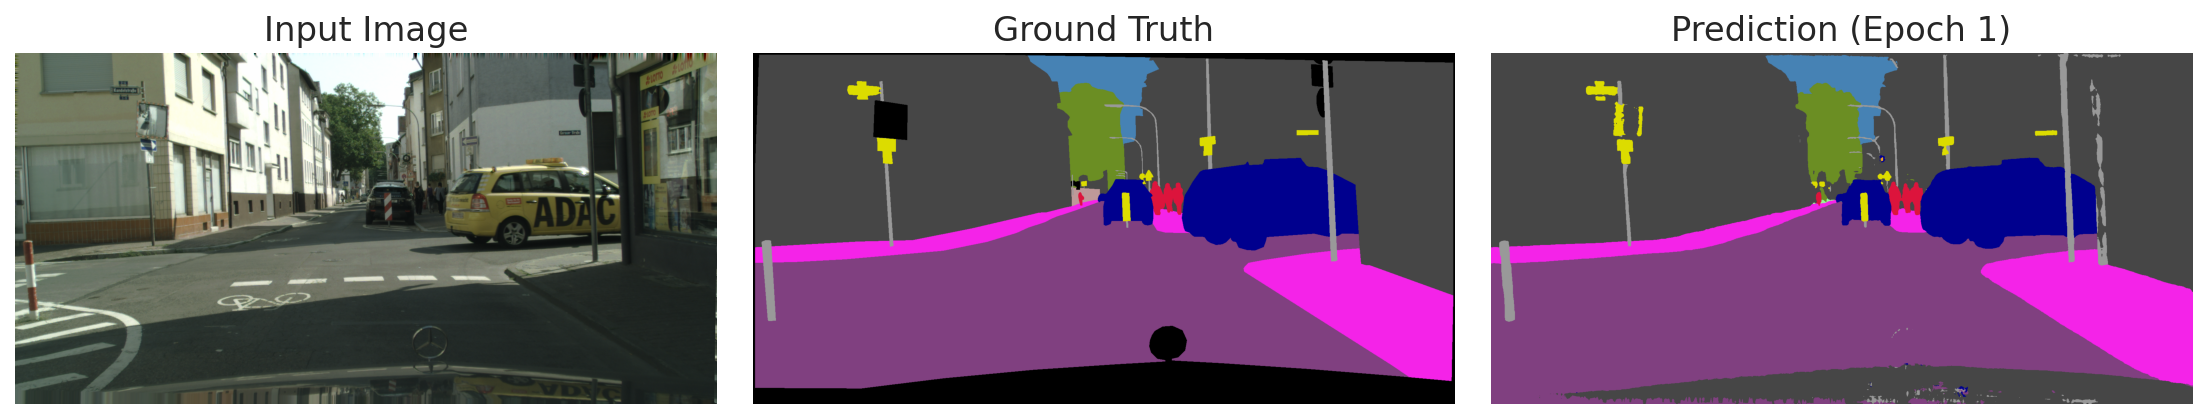

Saved qualitative comparison: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals/epoch_001_comparison.png



Epoch 2/80 | Phase 1
Train Total Loss: 14.6448 | Train Native: 13.0795 | Train CE: 1.1868 | Train Lovasz: 0.7554 | Train Boundary: 0.0055 | Train aAcc: 96.40
Val CE Loss: 0.4999 | Val aAcc: 95.87 | Val mAcc: 80.72 | Val mIoU: 76.93
LR Backbone: 0.00e+00 | LR Head: 2.23e-05
Epoch Time: 954.85s | ETA: 20:44:13
No mIoU improvement. Early-stop patience: 1/12



Epoch 3/80 | Phase 1
Train Total Loss: 13.7267 | Train Native: 12.8758 | Train CE: 0.5271 | Train Lovasz: 0.6460 | Train Boundary: 0.0053 | Train aAcc: 96.37
Val CE Loss: 0.4390 | Val aAcc: 95.98 | Val mAcc: 81.40 | Val mIoU: 77.55
LR Backbone: 0.00e+00 | LR Head: 3.35e-05
Epoch Time: 944.91s | ETA: 20:23:19
No mIoU improvement. Early-stop patience: 2/12



Epoch 4/80 | Phase 1
Train Total Loss: 13.7214 | Train Native: 12.9762 | Train CE: 0.4374 | Train Lovasz: 0.6140 | Train Boundary: 0.0054 | Train aAcc: 96.36
Val CE Loss: 0.3796 | Val aAcc: 96.15 | Val mAcc: 82.89 | Val mIoU: 77.98
LR Backbone: 0.00e+00 | LR Head: 4.46e-05
Epoch Time: 956.42s | ETA: 20:08:38
No mIoU improvement. Early-stop patience: 3/12



Epoch 5/80 | Phase 1
Train Total Loss: 13.7634 | Train Native: 13.0898 | Train CE: 0.3769 | Train Lovasz: 0.5919 | Train Boundary: 0.0053 | Train aAcc: 96.53
Val CE Loss: 0.3427 | Val aAcc: 96.27 | Val mAcc: 82.79 | Val mIoU: 78.49
LR Backbone: 0.00e+00 | LR Head: 5.58e-05
Epoch Time: 947.49s | ETA: 19:51:13
No mIoU improvement. Early-stop patience: 4/12


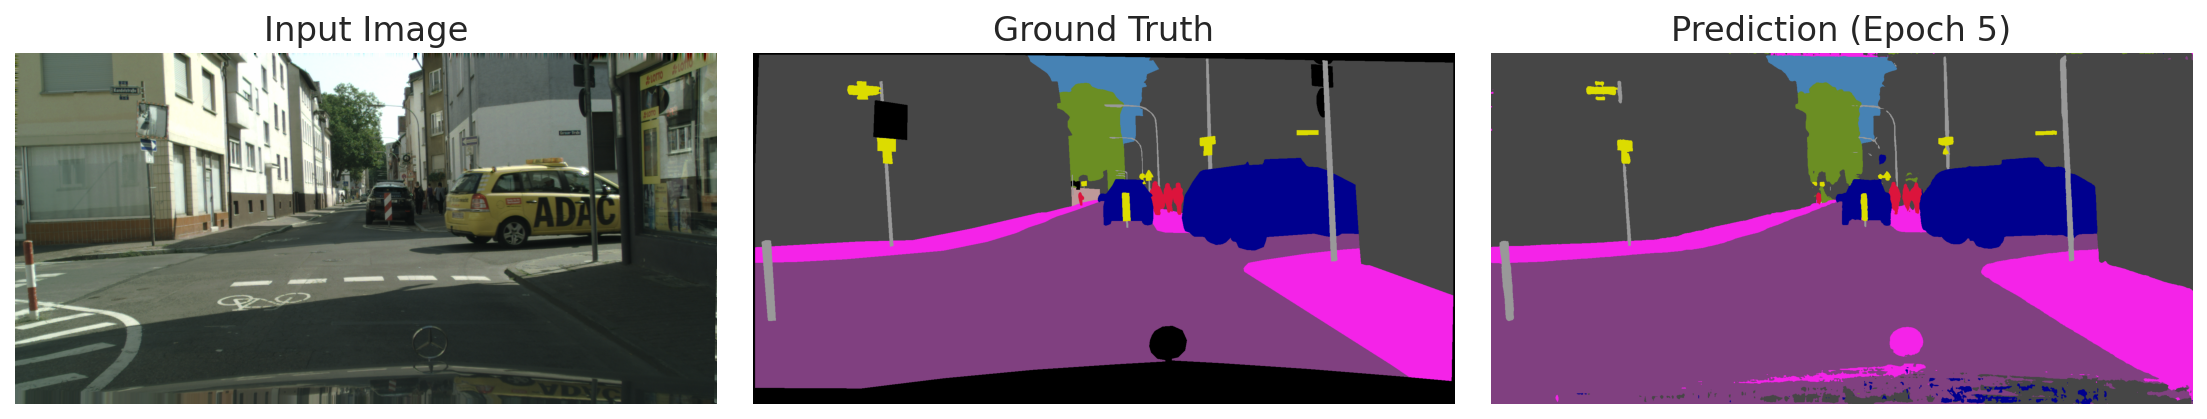

Saved qualitative comparison: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals/epoch_005_comparison.png



Epoch 6/80 | Phase 1
Train Total Loss: 13.9114 | Train Native: 13.2506 | Train CE: 0.3678 | Train Lovasz: 0.5844 | Train Boundary: 0.0054 | Train aAcc: 96.53
Val CE Loss: 0.3367 | Val aAcc: 96.37 | Val mAcc: 84.03 | Val mIoU: 79.34
LR Backbone: 0.00e+00 | LR Head: 5.95e-05
Epoch Time: 959.96s | ETA: 19:38:06
No mIoU improvement. Early-stop patience: 5/12



Epoch 7/80 | Phase 1
Train Total Loss: 13.9556 | Train Native: 13.3077 | Train CE: 0.3561 | Train Lovasz: 0.5819 | Train Boundary: 0.0053 | Train aAcc: 96.55
Val CE Loss: 0.3172 | Val aAcc: 96.21 | Val mAcc: 79.80 | Val mIoU: 75.13
LR Backbone: 0.00e+00 | LR Head: 5.88e-05
Epoch Time: 950.99s | ETA: 19:21:33
No mIoU improvement. Early-stop patience: 6/12



Epoch 8/80 | Phase 1
Train Total Loss: 13.9120 | Train Native: 13.2872 | Train CE: 0.3363 | Train Lovasz: 0.5755 | Train Boundary: 0.0053 | Train aAcc: 96.65
Val CE Loss: 0.3494 | Val aAcc: 96.41 | Val mAcc: 84.06 | Val mIoU: 79.82
LR Backbone: 0.00e+00 | LR Head: 5.81e-05
Epoch Time: 957.99s | ETA: 19:06:14
No mIoU improvement. Early-stop patience: 7/12



Epoch 9/80 | Phase 1
Train Total Loss: 13.6200 | Train Native: 13.0003 | Train CE: 0.3358 | Train Lovasz: 0.5662 | Train Boundary: 0.0054 | Train aAcc: 96.60
Val CE Loss: 0.3151 | Val aAcc: 96.41 | Val mAcc: 83.84 | Val mIoU: 79.30
LR Backbone: 0.00e+00 | LR Head: 5.74e-05
Epoch Time: 946.68s | ETA: 18:49:16
No mIoU improvement. Early-stop patience: 8/12



Epoch 10/80 | Phase 1
Train Total Loss: 13.7650 | Train Native: 13.1530 | Train CE: 0.3297 | Train Lovasz: 0.5630 | Train Boundary: 0.0053 | Train aAcc: 96.60
Val CE Loss: 0.3200 | Val aAcc: 96.36 | Val mAcc: 83.64 | Val mIoU: 79.41
LR Backbone: 0.00e+00 | LR Head: 5.66e-05
Epoch Time: 952.22s | ETA: 18:33:11
No mIoU improvement. Early-stop patience: 9/12


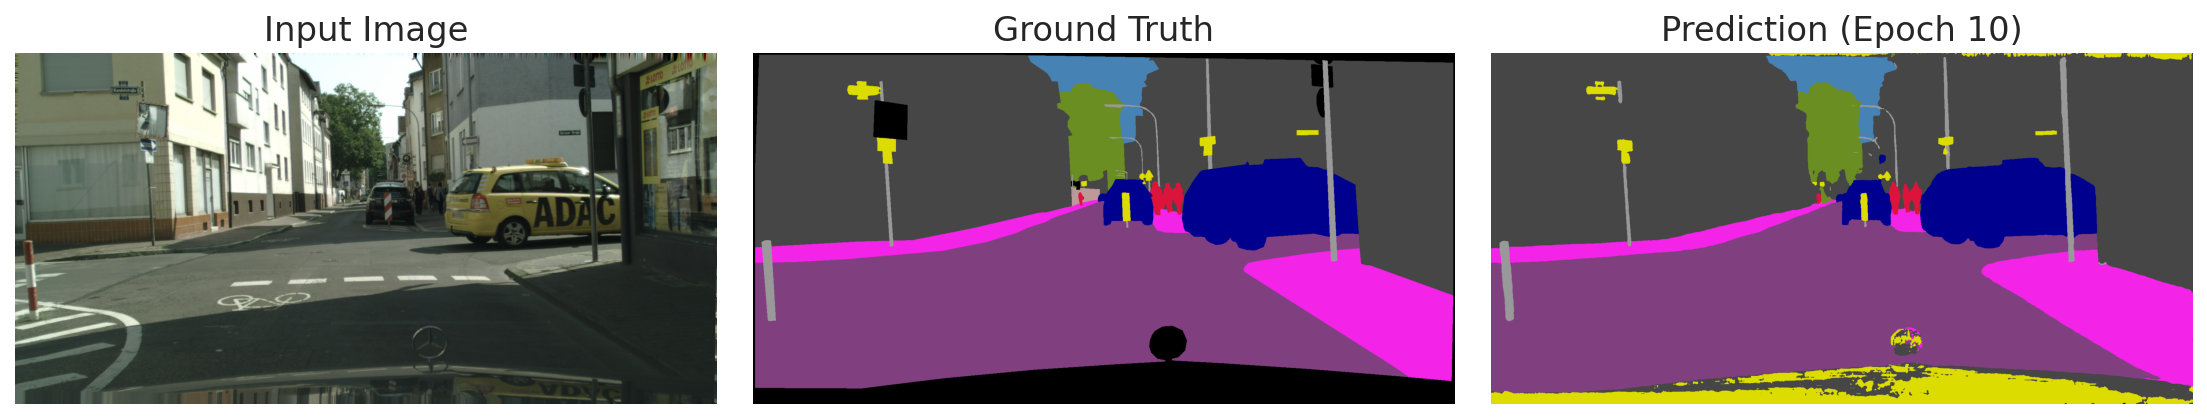

Saved qualitative comparison: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals/epoch_010_comparison.png



Epoch 11/80 | Phase 1
Train Total Loss: 13.8308 | Train Native: 13.2254 | Train CE: 0.3237 | Train Lovasz: 0.5618 | Train Boundary: 0.0054 | Train aAcc: 96.67
Val CE Loss: 0.3335 | Val aAcc: 96.48 | Val mAcc: 84.80 | Val mIoU: 80.28
LR Backbone: 0.00e+00 | LR Head: 5.59e-05
Epoch Time: 941.68s | ETA: 18:16:40
No mIoU improvement. Early-stop patience: 10/12



Epoch 12/80 | Phase 1
Train Total Loss: 13.6013 | Train Native: 13.0104 | Train CE: 0.3111 | Train Lovasz: 0.5578 | Train Boundary: 0.0054 | Train aAcc: 96.74
Val CE Loss: 0.2921 | Val aAcc: 96.45 | Val mAcc: 84.13 | Val mIoU: 79.74
LR Backbone: 0.00e+00 | LR Head: 5.52e-05
Epoch Time: 956.30s | ETA: 18:01:05
No mIoU improvement. Early-stop patience: 11/12



Epoch 13/80 | Phase 1
Train Total Loss: 13.5254 | Train Native: 12.9308 | Train CE: 0.3154 | Train Lovasz: 0.5568 | Train Boundary: 0.0056 | Train aAcc: 96.65
Val CE Loss: 0.3060 | Val aAcc: 96.39 | Val mAcc: 83.56 | Val mIoU: 79.49
LR Backbone: 0.00e+00 | LR Head: 5.45e-05
Epoch Time: 948.76s | ETA: 17:44:48
No mIoU improvement. Early-stop patience: 12/12



Epoch 14/80 | Phase 1
Train Total Loss: 13.5736 | Train Native: 12.9904 | Train CE: 0.3049 | Train Lovasz: 0.5551 | Train Boundary: 0.0054 | Train aAcc: 96.76
Val CE Loss: 0.3051 | Val aAcc: 96.47 | Val mAcc: 84.52 | Val mIoU: 80.15
LR Backbone: 0.00e+00 | LR Head: 5.37e-05
Epoch Time: 954.79s | ETA: 17:29:03
No mIoU improvement. Early-stop patience: 13/12



Epoch 15/80 | Phase 1
Train Total Loss: 13.5475 | Train Native: 12.9637 | Train CE: 0.3074 | Train Lovasz: 0.5513 | Train Boundary: 0.0054 | Train aAcc: 96.81
Val CE Loss: 0.3172 | Val aAcc: 96.51 | Val mAcc: 84.59 | Val mIoU: 80.26
LR Backbone: 0.00e+00 | LR Head: 5.30e-05
Epoch Time: 957.46s | ETA: 17:13:28
No mIoU improvement. Early-stop patience: 14/12


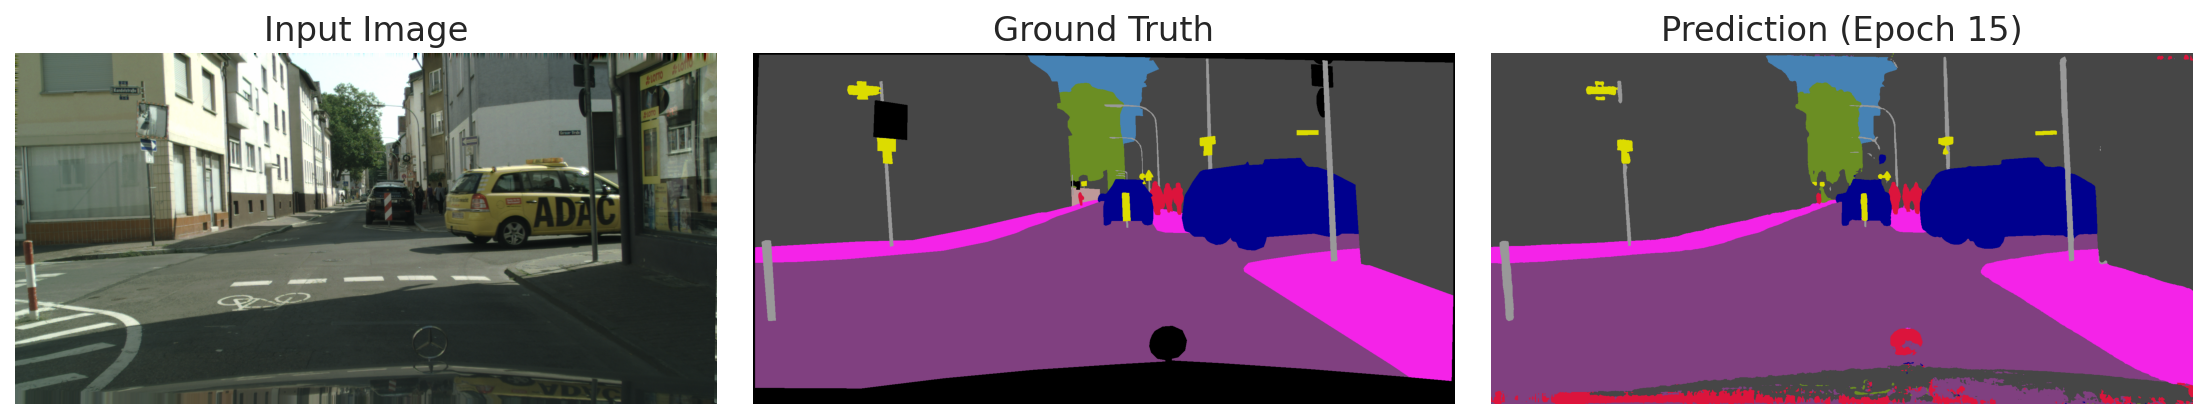

Saved qualitative comparison: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals/epoch_015_comparison.png



Epoch 16/80 | Phase 1
Train Total Loss: 13.7199 | Train Native: 13.1436 | Train CE: 0.3012 | Train Lovasz: 0.5486 | Train Boundary: 0.0053 | Train aAcc: 96.75
Val CE Loss: 0.3028 | Val aAcc: 96.46 | Val mAcc: 84.55 | Val mIoU: 80.03
LR Backbone: 0.00e+00 | LR Head: 5.23e-05
Epoch Time: 938.49s | ETA: 16:56:58
No mIoU improvement. Early-stop patience: 15/12



Epoch 17/80 | Phase 1
Train Total Loss: 13.6764 | Train Native: 13.1099 | Train CE: 0.2927 | Train Lovasz: 0.5459 | Train Boundary: 0.0054 | Train aAcc: 96.78
Val CE Loss: 0.2927 | Val aAcc: 96.44 | Val mAcc: 84.66 | Val mIoU: 79.93
LR Backbone: 0.00e+00 | LR Head: 5.15e-05
Epoch Time: 946.90s | ETA: 16:40:43
No mIoU improvement. Early-stop patience: 16/12



Epoch 18/80 | Phase 1
Train Total Loss: 13.7344 | Train Native: 13.1755 | Train CE: 0.2869 | Train Lovasz: 0.5422 | Train Boundary: 0.0053 | Train aAcc: 96.75
Val CE Loss: 0.2829 | Val aAcc: 96.41 | Val mAcc: 84.35 | Val mIoU: 79.82
LR Backbone: 0.00e+00 | LR Head: 5.08e-05
Epoch Time: 936.31s | ETA: 16:23:54
No mIoU improvement. Early-stop patience: 17/12



Epoch 19/80 | Phase 1
Train Total Loss: 13.7000 | Train Native: 13.1670 | Train CE: 0.2665 | Train Lovasz: 0.5315 | Train Boundary: 0.0054 | Train aAcc: 96.68
Val CE Loss: 0.2446 | Val aAcc: 96.47 | Val mAcc: 84.56 | Val mIoU: 80.04
LR Backbone: 0.00e+00 | LR Head: 5.00e-05
Epoch Time: 944.61s | ETA: 16:07:40
No mIoU improvement. Early-stop patience: 18/12



Epoch 20/80 | Phase 1
Train Total Loss: 13.9470 | Train Native: 13.4190 | Train CE: 0.2617 | Train Lovasz: 0.5310 | Train Boundary: 0.0053 | Train aAcc: 96.72
Val CE Loss: 0.2520 | Val aAcc: 96.45 | Val mAcc: 84.33 | Val mIoU: 79.89
LR Backbone: 0.00e+00 | LR Head: 4.93e-05
Epoch Time: 950.33s | ETA: 15:51:46
No mIoU improvement. Early-stop patience: 19/12


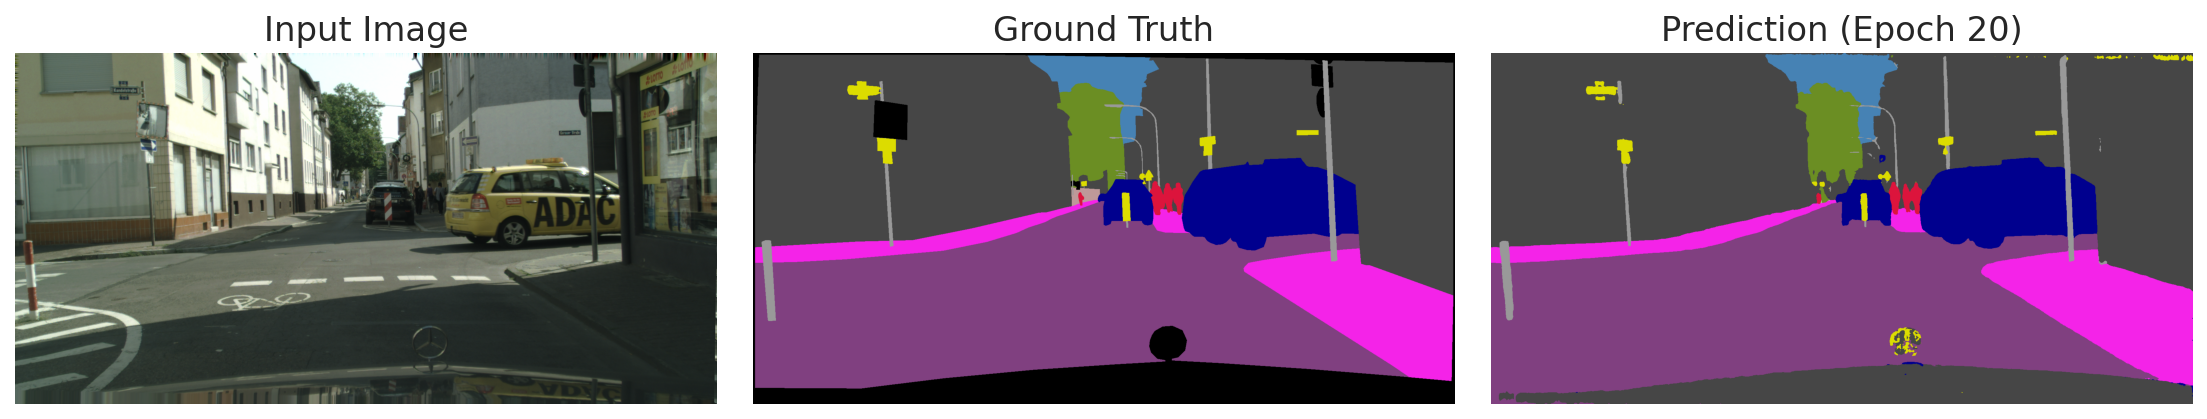

Saved qualitative comparison: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals/epoch_020_comparison.png
PHASE 2: Partial unfreeze

Epoch 21: entered Phase 2
Trainable params: 67,236,380 / 68,723,870



Epoch 21/80 | Phase 2
Train Total Loss: 14.0068 | Train Native: 13.4894 | Train CE: 0.2509 | Train Lovasz: 0.5313 | Train Boundary: 0.0053 | Train aAcc: 96.74
Val CE Loss: 0.2499 | Val aAcc: 96.47 | Val mAcc: 84.80 | Val mIoU: 79.90
LR Backbone: 1.62e-06 | LR Head: 1.62e-05
Epoch Time: 1250.38s | ETA: 15:50:11
No mIoU improvement. Early-stop patience: 20/12



Epoch 22/80 | Phase 2
Train Total Loss: 13.6689 | Train Native: 13.1573 | Train CE: 0.2497 | Train Lovasz: 0.5220 | Train Boundary: 0.0054 | Train aAcc: 96.77
Val CE Loss: 0.2425 | Val aAcc: 96.47 | Val mAcc: 84.67 | Val mIoU: 80.02
LR Backbone: 1.59e-06 | LR Head: 1.59e-05
Epoch Time: 1234.44s | ETA: 15:45:55
No mIoU improvement. Early-stop patience: 21/12



Epoch 23/80 | Phase 2
Train Total Loss: 13.7349 | Train Native: 13.2218 | Train CE: 0.2497 | Train Lovasz: 0.5252 | Train Boundary: 0.0053 | Train aAcc: 96.74
Val CE Loss: 0.2386 | Val aAcc: 96.46 | Val mAcc: 84.64 | Val mIoU: 80.03
LR Backbone: 1.57e-06 | LR Head: 1.57e-05
Epoch Time: 1230.86s | ETA: 15:40:05
No mIoU improvement. Early-stop patience: 22/12



Epoch 24/80 | Phase 2
Train Total Loss: 13.4704 | Train Native: 12.9604 | Train CE: 0.2463 | Train Lovasz: 0.5259 | Train Boundary: 0.0054 | Train aAcc: 96.75
Val CE Loss: 0.2373 | Val aAcc: 96.40 | Val mAcc: 83.99 | Val mIoU: 79.25
LR Backbone: 1.54e-06 | LR Head: 1.54e-05
Epoch Time: 1232.47s | ETA: 15:33:05
No mIoU improvement. Early-stop patience: 23/12



Epoch 25/80 | Phase 2
Train Total Loss: 13.6247 | Train Native: 13.1155 | Train CE: 0.2461 | Train Lovasz: 0.5245 | Train Boundary: 0.0053 | Train aAcc: 96.83
Val CE Loss: 0.2414 | Val aAcc: 96.45 | Val mAcc: 84.27 | Val mIoU: 79.35
LR Backbone: 1.52e-06 | LR Head: 1.52e-05
Epoch Time: 1235.21s | ETA: 15:25:06
No mIoU improvement. Early-stop patience: 24/12


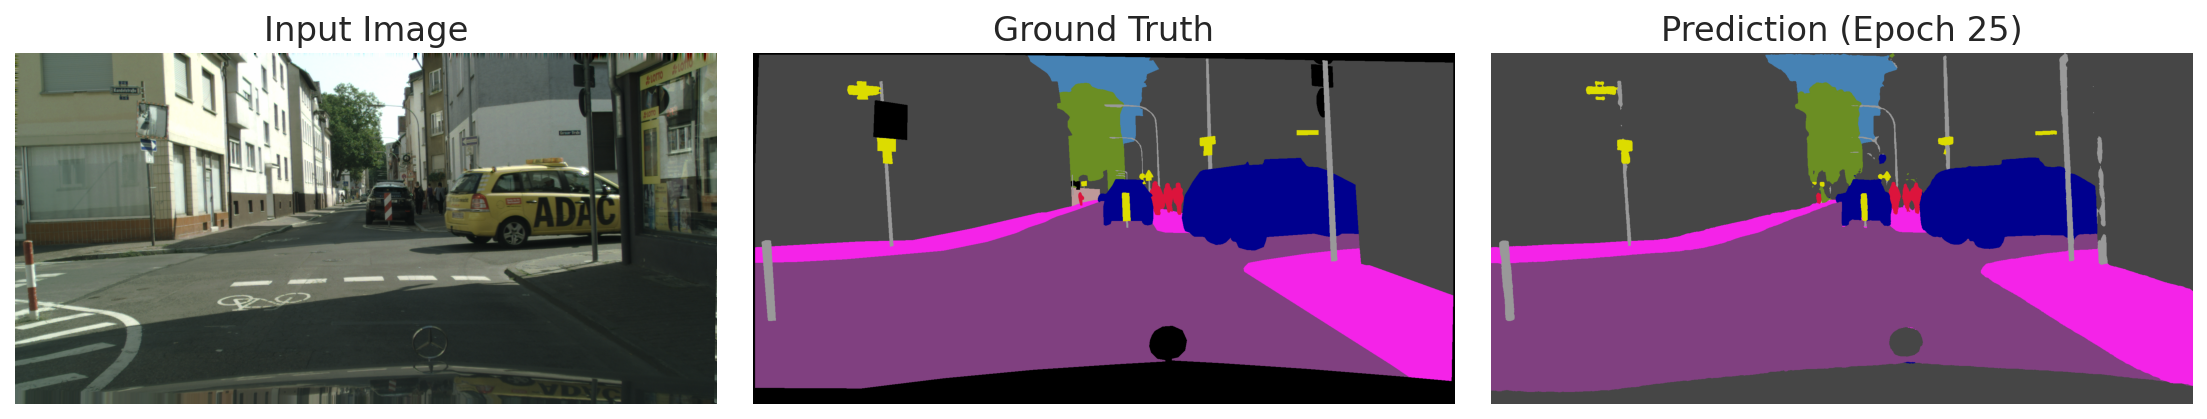

Saved qualitative comparison: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/training_visuals/epoch_025_comparison.png
Early stopping triggered at epoch 25

Training completed
Total training time: 7:00:38
Best epoch: 1
Best validation mIoU: 81.77
Best validation mAcc: 88.29
Best validation aAcc: 96.66
Best checkpoint: progressive_checkpoints_swinsmall/best_miou_checkpoint.pt
Latest checkpoint: progressive_checkpoints_swinsmall/latest_checkpoint.pt
Metrics CSV: training_metrics_swinsmall/training_metrics.csv
Metrics XLSX: training_metrics_swinsmall/training_metrics.xlsx


In [7]:
# ============================================================
# STEP 5: TRAINING LOOP
# For: Mask2Former + Swin-Small
# Revised for stable training, reduced overfitting, honest metrics,
# adaptive phase transitions, sliding-window validation, early stopping,
# qualitative visual saving every 5 epochs, and fixed differentiable boundary loss
# ============================================================

import os
import gc
import math
import time
from datetime import timedelta

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_globals = [
    "model", "train_loader", "val_loader", "optimizer", "scheduler",
    "build_semantic_targets_from_instance_targets",
    "compute_metrics", "set_model_phase", "get_current_phase",
    "get_optimizer_for_phase", "CHECKPOINT_DIR", "METRICS_DIR", "history",
    "best_record", "DEVICE", "CLASSES", "IGNORE_INDEX", "GRAD_ACCUM_STEPS",
    "EPOCHS", "GRAD_CLIP_NORM", "WARMUP_STEPS", "POLY_POWER",
    "CE_WEIGHT", "LOVASZ_WEIGHT", "USE_LOVASZ",
    "USE_BOUNDARY_LOSS", "BOUNDARY_LOSS_WEIGHT",
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables/functions from previous steps: {missing}")

DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = globals().get("USE_AMP", torch.cuda.is_available())

USE_SLIDING_WINDOW_VAL = globals().get("USE_SLIDING_WINDOW_VAL", True)
VAL_WINDOW_SIZE = globals().get("VAL_WINDOW_SIZE", (512, 1024))
VAL_WINDOW_STRIDE = globals().get("VAL_WINDOW_STRIDE", (341, 682))

EARLY_STOPPING_PATIENCE = globals().get("EARLY_STOPPING_PATIENCE", 12)
MIN_EPOCHS_BEFORE_EARLY_STOP = globals().get("MIN_EPOCHS_BEFORE_EARLY_STOP", 25)
MIN_DELTA_MIOU = globals().get("MIN_DELTA_MIOU", 0.001)

CE_WEIGHT = globals().get("CE_WEIGHT", 1.0)
LOVASZ_WEIGHT = globals().get("LOVASZ_WEIGHT", 0.5)
USE_LOVASZ = globals().get("USE_LOVASZ", True)

USE_BOUNDARY_LOSS = globals().get("USE_BOUNDARY_LOSS", True)
BOUNDARY_LOSS_WEIGHT = globals().get("BOUNDARY_LOSS_WEIGHT", 0.15)

USE_FULL_UNFREEZE_PHASE = globals().get("USE_FULL_UNFREEZE_PHASE", False)

CHECKPOINT_DIR = str(CHECKPOINT_DIR)
METRICS_DIR = str(METRICS_DIR)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# ------------------------------------------------------------
# PATCHED LOSS HELPERS
# These are redefined here so Step 5 works safely even if Step 4
# was not rerun after fixes.
# ------------------------------------------------------------
def lovasz_grad_step5(gt_sorted: torch.Tensor) -> torch.Tensor:
    p = len(gt_sorted)
    gts = gt_sorted.sum()

    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / (union + 1e-10)

    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]

    return jaccard

def _safe_mean_step5(losses, device):
    if len(losses) == 0:
        return torch.tensor(0.0, device=device, requires_grad=True)
    return sum(losses) / len(losses)

def lovasz_softmax_flat_step5(probs: torch.Tensor, labels: torch.Tensor, classes="present") -> torch.Tensor:
    if probs.numel() == 0:
        return torch.tensor(0.0, device=probs.device, requires_grad=True)

    C = probs.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ["all", "present"] else classes

    for c in class_to_sum:
        fg = (labels == c).float()
        if classes == "present" and fg.sum() == 0:
            continue

        class_pred = probs[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, descending=True)
        fg_sorted = fg[perm]

        losses.append(torch.dot(errors_sorted, lovasz_grad_step5(fg_sorted)))

    return _safe_mean_step5(losses, probs.device)

def lovasz_softmax_from_logits_step5(logits: torch.Tensor, labels: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    probs = F.softmax(logits, dim=1)
    valid_mask = (labels != ignore_index)

    if valid_mask.sum() == 0:
        return torch.tensor(0.0, device=logits.device, requires_grad=True)

    probs_valid = probs.permute(0, 2, 3, 1)[valid_mask]
    labels_valid = labels[valid_mask]

    return lovasz_softmax_flat_step5(probs_valid, labels_valid, classes="present")

# ------------------------------------------------------------
# DIFFERENTIABLE BOUNDARY LOSS HELPERS
# ------------------------------------------------------------
def compute_boundary_target_step5(targets: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    """
    targets: [B, H, W] long
    returns: [B, 1, H, W] float in {0,1}
    """
    boundary = torch.zeros_like(targets, dtype=torch.bool)
    valid = (targets != ignore_index)

    # horizontal change
    boundary[:, :, 1:] |= (
        (targets[:, :, 1:] != targets[:, :, :-1]) &
        valid[:, :, 1:] &
        valid[:, :, :-1]
    )

    # vertical change
    boundary[:, 1:, :] |= (
        (targets[:, 1:, :] != targets[:, :-1, :]) &
        valid[:, 1:, :] &
        valid[:, :-1, :]
    )

    return boundary.unsqueeze(1).float()

def compute_soft_boundary_map_step5(semantic_logits: torch.Tensor) -> torch.Tensor:
    """
    semantic_logits: [B, C, H, W]
    returns: soft boundary map [B, 1, H, W]
    Differentiable boundary intensity computed from class probability changes.
    """
    probs = F.softmax(semantic_logits.float(), dim=1)

    B, C, H, W = probs.shape
    boundary = torch.zeros((B, 1, H, W), device=probs.device, dtype=probs.dtype)

    # horizontal probability difference
    dh = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1]).mean(dim=1, keepdim=True)
    boundary[:, :, :, 1:] += dh

    # vertical probability difference
    dv = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :]).mean(dim=1, keepdim=True)
    boundary[:, :, 1:, :] += dv

    # normalize to [0,1] softly
    boundary = boundary.clamp(min=0.0, max=1.0)
    return boundary

def compute_boundary_loss_step5(semantic_logits: torch.Tensor, dense_targets: torch.Tensor, ignore_index: int = 255) -> torch.Tensor:
    """
    Differentiable boundary consistency loss.
    Uses Smooth L1 between soft predicted boundary intensity and GT boundary map.
    Safe under mixed precision because computation is promoted to float32.
    """
    with torch.no_grad():
        target_boundary = compute_boundary_target_step5(dense_targets, ignore_index=ignore_index)

    pred_boundary = compute_soft_boundary_map_step5(semantic_logits)

    return F.smooth_l1_loss(pred_boundary.float(), target_boundary.float())

# ------------------------------------------------------------
# PATCHED HYBRID LOSS
# ------------------------------------------------------------
def compute_hybrid_loss_step5(
    outputs,
    dense_targets,
    ce_weight=1.0,
    lovasz_weight=0.5,
    use_lovasz=True,
    use_boundary_loss=False,
    boundary_loss_weight=0.15
):
    native_loss = outputs.loss if outputs.loss is not None else torch.tensor(0.0, device=dense_targets.device)

    mask_preds = outputs.masks_queries_logits
    class_logits = outputs.class_queries_logits

    H, W = dense_targets.shape[1], dense_targets.shape[2]

    mask_preds_up = F.interpolate(
        mask_preds,
        size=(H, W),
        mode="bilinear",
        align_corners=False
    )

    mask_cls = F.softmax(class_logits, dim=-1)[..., :-1]
    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())

    ce_loss = F.cross_entropy(
        semantic_logits,
        dense_targets,
        ignore_index=IGNORE_INDEX
    )

    if use_lovasz:
        lovasz_loss = lovasz_softmax_from_logits_step5(
            semantic_logits,
            dense_targets,
            ignore_index=IGNORE_INDEX
        )
    else:
        lovasz_loss = torch.tensor(0.0, device=dense_targets.device)

    if use_boundary_loss:
        # compute in float32-safe path
        boundary_loss = compute_boundary_loss_step5(
            semantic_logits.float(),
            dense_targets,
            ignore_index=IGNORE_INDEX
        )
    else:
        boundary_loss = torch.tensor(0.0, device=dense_targets.device)

    total_loss = (
        native_loss
        + (ce_weight * ce_loss)
        + (lovasz_weight * lovasz_loss)
        + (boundary_loss_weight * boundary_loss)
    )

    loss_dict = {
        "native_loss": float(native_loss.detach().item()),
        "ce_loss": float(ce_loss.detach().item()),
        "lovasz_loss": float(lovasz_loss.detach().item()),
        "boundary_loss": float(boundary_loss.detach().item()),
        "total_loss": float(total_loss.detach().item())
    }

    return total_loss, loss_dict, semantic_logits

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_lr_snapshot(optimizer):
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    if len(lrs) == 1:
        return 0.0, lrs[0]
    return lrs[0], lrs[1]

def make_phase_scheduler(optimizer, global_update_step, total_update_steps, warmup_steps=2000, power=0.9):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))

        progress = float(current_step - warmup_steps) / float(max(1, total_update_steps - warmup_steps))
        progress = min(max(progress, 0.0), 1.0)
        return (1.0 - progress) ** power

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lr_lambda,
        last_epoch=-1
    )

    for _ in range(global_update_step):
        scheduler.step()

    return scheduler

def save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    epoch,
    global_update_step,
    best_record,
    history
):
    ckpt = {
        "epoch": epoch,
        "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "best_record": best_record,
        "history": history,
    }
    torch.save(ckpt, path)

def sliding_window_inference(
    model,
    image,
    window_size=(512, 1024),
    stride=(341, 682),
    num_classes=19,
    use_amp=True
):
    assert image.ndim == 4, "Expected image tensor of shape [B, C, H, W]"

    B, C, H, W = image.shape
    h_crop, w_crop = window_size
    h_stride, w_stride = stride

    if H <= h_crop:
        ys = [0]
    else:
        ys = list(range(0, H - h_crop + 1, h_stride))
        if ys[-1] != H - h_crop:
            ys.append(H - h_crop)

    if W <= w_crop:
        xs = [0]
    else:
        xs = list(range(0, W - w_crop + 1, w_stride))
        if xs[-1] != W - w_crop:
            xs.append(W - w_crop)

    full_logits = torch.zeros((B, num_classes, H, W), device=image.device, dtype=torch.float32)
    count_map = torch.zeros((B, 1, H, W), device=image.device, dtype=torch.float32)

    for y1 in ys:
        y2 = min(y1 + h_crop, H)
        for x1 in xs:
            x2 = min(x1 + w_crop, W)

            crop = image[:, :, y1:y2, x1:x2]

            with torch.no_grad():
                with torch.autocast(device_type="cuda", enabled=(use_amp and image.is_cuda)):
                    outputs = model(pixel_values=crop)

                    mask_preds = F.interpolate(
                        outputs.masks_queries_logits,
                        size=(y2 - y1, x2 - x1),
                        mode="bilinear",
                        align_corners=False
                    )
                    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                    crop_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())

            full_logits[:, :, y1:y2, x1:x2] += crop_logits.float()
            count_map[:, :, y1:y2, x1:x2] += 1.0

    full_logits = full_logits / count_map.clamp_min(1.0)
    return full_logits

# ------------------------------------------------------------
# TRACKERS
# ------------------------------------------------------------
excel_rows = []
best_conf_matrix = None
best_metrics = None

global_update_step = 0
current_phase = None
patience_counter = 0

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
total_update_steps = steps_per_epoch * EPOCHS

training_start_time = time.time()

print(f"Starting training for {EPOCHS} epochs")
print(f"Effective batch size: {globals().get('BATCH_SIZE', 1) * GRAD_ACCUM_STEPS}")
print(f"Sliding-window validation: {USE_SLIDING_WINDOW_VAL}")
print(f"Boundary loss enabled: {USE_BOUNDARY_LOSS}")
print(f"Qualitative visuals every 5 epochs: True")

# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------
for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()

    # ------------------------
    # Phase management
    # ------------------------
    desired_phase = get_current_phase(epoch)

    if desired_phase != current_phase:
        current_phase = desired_phase

        set_model_phase(model, phase=current_phase, use_full_unfreeze_phase=USE_FULL_UNFREEZE_PHASE)
        optimizer = get_optimizer_for_phase(model, current_phase)
        scheduler = make_phase_scheduler(
            optimizer=optimizer,
            global_update_step=global_update_step,
            total_update_steps=total_update_steps,
            warmup_steps=WARMUP_STEPS,
            power=POLY_POWER
        )

        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\nEpoch {epoch}: entered Phase {current_phase}")
        print(f"Trainable params: {trainable_params:,} / {total_params:,}")

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ------------------------
    # Train
    # ------------------------
    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_total_loss_sum = 0.0
    train_native_loss_sum = 0.0
    train_ce_loss_sum = 0.0
    train_lovasz_loss_sum = 0.0
    train_boundary_loss_sum = 0.0

    train_correct = 0
    train_total = 0
    train_batches = 0

    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for step, (images, mask_labels, class_labels) in enumerate(train_pbar, start=1):
        images = images.to(DEVICE, non_blocking=True)
        mask_labels = [m.to(DEVICE, non_blocking=True) for m in mask_labels]
        class_labels = [c.to(DEVICE, non_blocking=True) for c in class_labels]

        _, _, curr_h, curr_w = images.shape
        dense_targets = build_semantic_targets_from_instance_targets(
            mask_labels=mask_labels,
            class_labels=class_labels,
            image_size=(curr_h, curr_w),
            ignore_index=IGNORE_INDEX
        )

        with torch.autocast(device_type="cuda", enabled=(USE_AMP and images.is_cuda)):
            outputs = model(
                pixel_values=images,
                mask_labels=mask_labels,
                class_labels=class_labels
            )

            total_loss, loss_dict, semantic_logits = compute_hybrid_loss_step5(
                outputs=outputs,
                dense_targets=dense_targets,
                ce_weight=CE_WEIGHT,
                lovasz_weight=LOVASZ_WEIGHT,
                use_lovasz=USE_LOVASZ,
                use_boundary_loss=USE_BOUNDARY_LOSS,
                boundary_loss_weight=BOUNDARY_LOSS_WEIGHT
            )

            loss = total_loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        train_total_loss_sum += loss_dict["total_loss"]
        train_native_loss_sum += loss_dict["native_loss"]
        train_ce_loss_sum += loss_dict["ce_loss"]
        train_lovasz_loss_sum += loss_dict["lovasz_loss"]
        train_boundary_loss_sum += loss_dict.get("boundary_loss", 0.0)
        train_batches += 1

        with torch.no_grad():
            preds = torch.argmax(semantic_logits, dim=1)
            valid = (dense_targets != IGNORE_INDEX)
            if valid.any():
                train_correct += (preds[valid] == dense_targets[valid]).sum().item()
                train_total += valid.sum().item()

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            scheduler.step()
            global_update_step += 1

        lr_backbone, lr_head = get_lr_snapshot(optimizer)
        train_pbar.set_postfix(
            total_loss=f"{train_total_loss_sum / max(1, train_batches):.4f}",
            ce=f"{train_ce_loss_sum / max(1, train_batches):.4f}",
            lovasz=f"{train_lovasz_loss_sum / max(1, train_batches):.4f}",
            boundary=f"{train_boundary_loss_sum / max(1, train_batches):.4f}",
            lr_head=f"{lr_head:.2e}"
        )

    train_total_loss = train_total_loss_sum / max(1, train_batches)
    train_native_loss = train_native_loss_sum / max(1, train_batches)
    train_ce_loss = train_ce_loss_sum / max(1, train_batches)
    train_lovasz_loss = train_lovasz_loss_sum / max(1, train_batches)
    train_boundary_loss = train_boundary_loss_sum / max(1, train_batches)
    train_aAcc = train_correct / (train_total + 1e-10)

    # ------------------------
    # Validation
    # ------------------------
    model.eval()

    val_ce_loss_sum = 0.0
    val_total_batches = 0
    conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)

    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False)

    with torch.no_grad():
        for images, mask_labels, class_labels in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            mask_labels = [m.to(DEVICE, non_blocking=True) for m in mask_labels]
            class_labels = [c.to(DEVICE, non_blocking=True) for c in class_labels]

            _, _, val_h, val_w = images.shape
            dense_targets = build_semantic_targets_from_instance_targets(
                mask_labels=mask_labels,
                class_labels=class_labels,
                image_size=(val_h, val_w),
                ignore_index=IGNORE_INDEX
            )

            if USE_SLIDING_WINDOW_VAL:
                semantic_logits = sliding_window_inference(
                    model=model,
                    image=images,
                    window_size=VAL_WINDOW_SIZE,
                    stride=VAL_WINDOW_STRIDE,
                    num_classes=CLASSES,
                    use_amp=USE_AMP
                )
            else:
                with torch.autocast(device_type="cuda", enabled=(USE_AMP and images.is_cuda)):
                    outputs = model(pixel_values=images)
                    mask_preds = F.interpolate(
                        outputs.masks_queries_logits,
                        size=(val_h, val_w),
                        mode="bilinear",
                        align_corners=False
                    )
                    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())

            ce_loss = F.cross_entropy(
                semantic_logits,
                dense_targets,
                ignore_index=IGNORE_INDEX
            )
            val_ce_loss_sum += ce_loss.item()
            val_total_batches += 1

            preds = torch.argmax(semantic_logits, dim=1)

            preds_np = preds.detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)

            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                conf_matrix += fast_confusion_matrix(
                    y_true=targets_np[valid],
                    y_pred=preds_np[valid],
                    num_classes=CLASSES
                )

            val_metrics_preview = compute_metrics(conf_matrix)
            val_pbar.set_postfix(
                val_ce=f"{val_ce_loss_sum / max(1, val_total_batches):.4f}",
                mIoU=f"{val_metrics_preview['mIoU'] * 100:.2f}"
            )

    metrics = compute_metrics(conf_matrix)
    val_ce_loss = val_ce_loss_sum / max(1, val_total_batches)

    # ------------------------
    # Bookkeeping
    # ------------------------
    epoch_time = time.time() - epoch_start_time
    elapsed = time.time() - training_start_time
    avg_epoch_time = elapsed / epoch
    eta_seconds = avg_epoch_time * (EPOCHS - epoch)
    eta_str = str(timedelta(seconds=int(eta_seconds)))

    lr_backbone, lr_head = get_lr_snapshot(optimizer)

    history["epoch"].append(epoch)
    history["train_total_loss"].append(train_total_loss)
    history["train_native_loss"].append(train_native_loss)
    history["train_ce_loss"].append(train_ce_loss)
    history["train_lovasz_loss"].append(train_lovasz_loss)
    history["val_total_loss"].append(val_ce_loss)
    history["val_ce_loss"].append(val_ce_loss)
    history["val_miou"].append(metrics["mIoU"])
    history["val_macc"].append(metrics["mAcc"])
    history["val_aacc"].append(metrics["aAcc"])
    history["backbone_lr"].append(lr_backbone)
    history["head_lr"].append(lr_head)
    history["phase"].append(current_phase)
    history["epoch_time_sec"].append(epoch_time)

    excel_rows.append({
        "Epoch": epoch,
        "Phase": current_phase,
        "Train_Total_Loss": train_total_loss,
        "Train_Native_Loss": train_native_loss,
        "Train_CE_Loss": train_ce_loss,
        "Train_Lovasz_Loss": train_lovasz_loss,
        "Train_Boundary_Loss": train_boundary_loss,
        "Train_aAcc": train_aAcc,
        "Val_CE_Loss": val_ce_loss,
        "Val_mIoU": metrics["mIoU"],
        "Val_mAcc": metrics["mAcc"],
        "Val_aAcc": metrics["aAcc"],
        "LR_Backbone": lr_backbone,
        "LR_Head": lr_head,
        "Epoch_Time_sec": epoch_time,
    })

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Phase {current_phase}\n"
        f"Train Total Loss: {train_total_loss:.4f} | Train Native: {train_native_loss:.4f} | Train CE: {train_ce_loss:.4f} | Train Lovasz: {train_lovasz_loss:.4f} | Train Boundary: {train_boundary_loss:.4f} | Train aAcc: {train_aAcc*100:.2f}\n"
        f"Val CE Loss: {val_ce_loss:.4f} | Val aAcc: {metrics['aAcc']*100:.2f} | Val mAcc: {metrics['mAcc']*100:.2f} | Val mIoU: {metrics['mIoU']*100:.2f}\n"
        f"LR Backbone: {lr_backbone:.2e} | LR Head: {lr_head:.2e}\n"
        f"Epoch Time: {epoch_time:.2f}s | ETA: {eta_str}"
    )

    # ------------------------
    # Save latest checkpoint every epoch
    # ------------------------
    latest_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pt")
    save_checkpoint(
        path=latest_path,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        epoch=epoch,
        global_update_step=global_update_step,
        best_record=best_record,
        history=history
    )

    # Periodic checkpoint every 5 epochs
    if epoch % 5 == 0:
        periodic_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch:03d}.pt")
        save_checkpoint(
            path=periodic_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            global_update_step=global_update_step,
            best_record=best_record,
            history=history
        )

    # ------------------------
    # Save best checkpoint
    # ------------------------
    improved = metrics["mIoU"] > (best_record["best_miou"] + MIN_DELTA_MIOU)

    if improved:
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = metrics["mIoU"]
        best_record["best_macc"] = metrics["mAcc"]
        best_record["best_aacc"] = metrics["aAcc"]

        best_conf_matrix = conf_matrix.copy()
        best_metrics = metrics.copy()

        save_checkpoint(
            path=best_record["best_path"],
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            global_update_step=global_update_step,
            best_record=best_record,
            history=history
        )

        patience_counter = 0
        print(f"New best checkpoint saved at epoch {epoch}")
    else:
        patience_counter += 1
        print(f"No mIoU improvement. Early-stop patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

    # ------------------------
    # Save metrics table every epoch
    # ------------------------
    metrics_df = pd.DataFrame(excel_rows)
    metrics_csv_path = os.path.join(METRICS_DIR, "training_metrics.csv")
    metrics_xlsx_path = os.path.join(METRICS_DIR, "training_metrics.xlsx")

    metrics_df.to_csv(metrics_csv_path, index=False)
    try:
        metrics_df.to_excel(metrics_xlsx_path, index=False)
    except Exception:
        pass

    # ------------------------
    # Periodic qualitative visualization every 5 epochs
    # Images are saved at 600 dpi because Step 2 uses dpi=600 in visualize_results(...)
    # ------------------------
    if "visualize_results" in globals():
        if (epoch % 5 == 0) or improved:
            try:
                visualize_results(
                    loader=val_loader,
                    model=model,
                    epoch=epoch,
                    save_path=QUAL_VIS_DIR if "QUAL_VIS_DIR" in globals() else None,
                    max_images=3
                )
            except Exception as e:
                print(f"Qualitative visualization skipped at epoch {epoch}: {e}")

    # ------------------------
    # Early stopping
    # ------------------------
    if (epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP) and (patience_counter >= EARLY_STOPPING_PATIENCE):
        print(f"Early stopping triggered at epoch {epoch}")
        break

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------
total_training_time = time.time() - training_start_time
print("\nTraining completed")
print(f"Total training time: {str(timedelta(seconds=int(total_training_time)))}")
print(f"Best epoch: {best_record['best_epoch']}")
print(f"Best validation mIoU: {best_record['best_miou'] * 100:.2f}")
print(f"Best validation mAcc: {best_record['best_macc'] * 100:.2f}")
print(f"Best validation aAcc: {best_record['best_aacc'] * 100:.2f}")
print(f"Best checkpoint: {best_record['best_path']}")
print(f"Latest checkpoint: {os.path.join(CHECKPOINT_DIR, 'latest_checkpoint.pt')}")
print(f"Metrics CSV: {os.path.join(METRICS_DIR, 'training_metrics.csv')}")
print(f"Metrics XLSX: {os.path.join(METRICS_DIR, 'training_metrics.xlsx')}")

# Keep best confusion matrix and best metrics available in memory
BEST_CONF_MATRIX = best_conf_matrix
BEST_METRICS = best_metrics

Final export directory: /home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/Results_Export


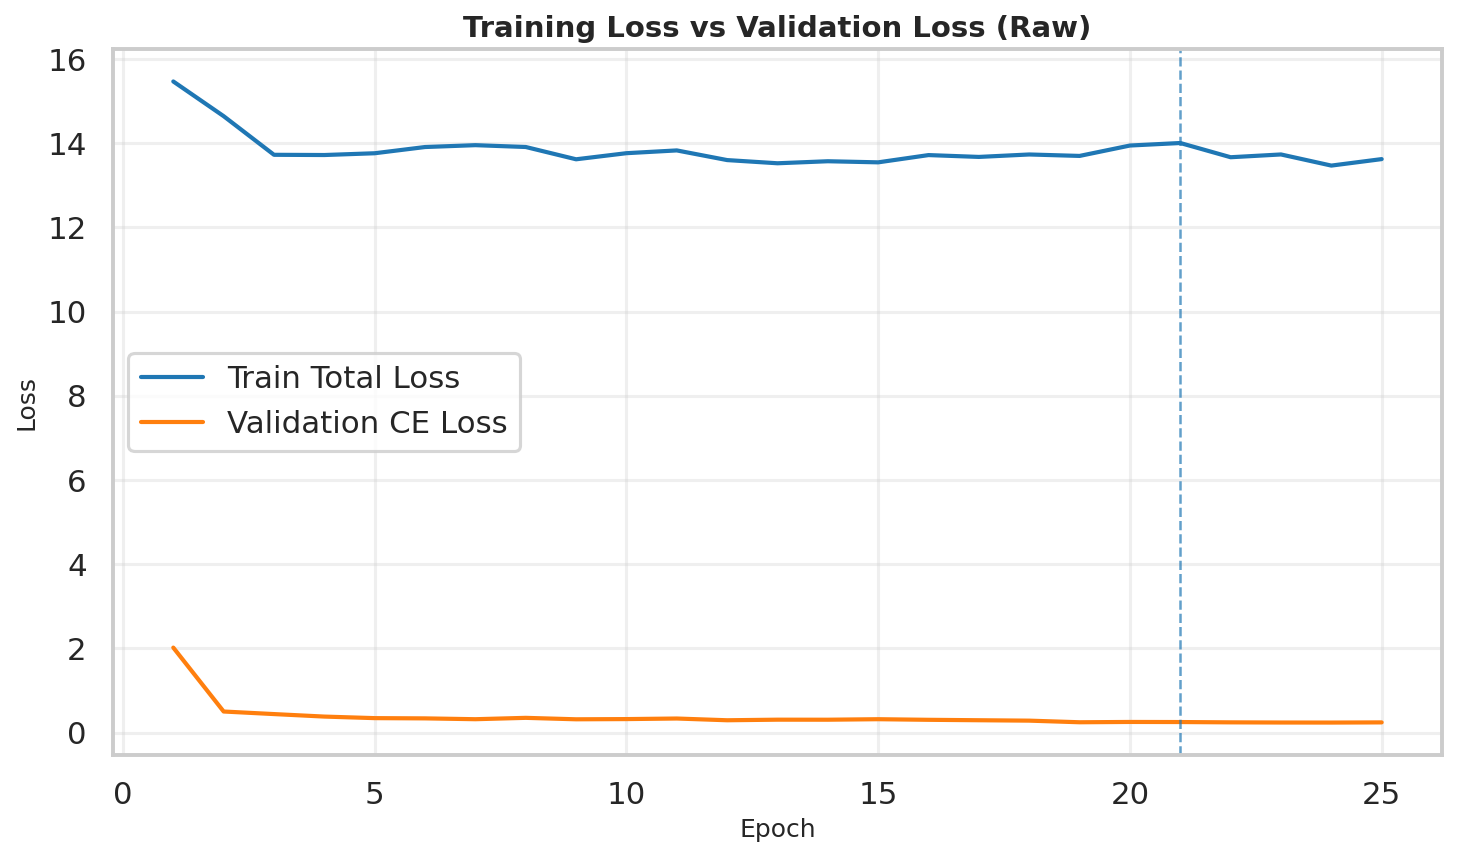

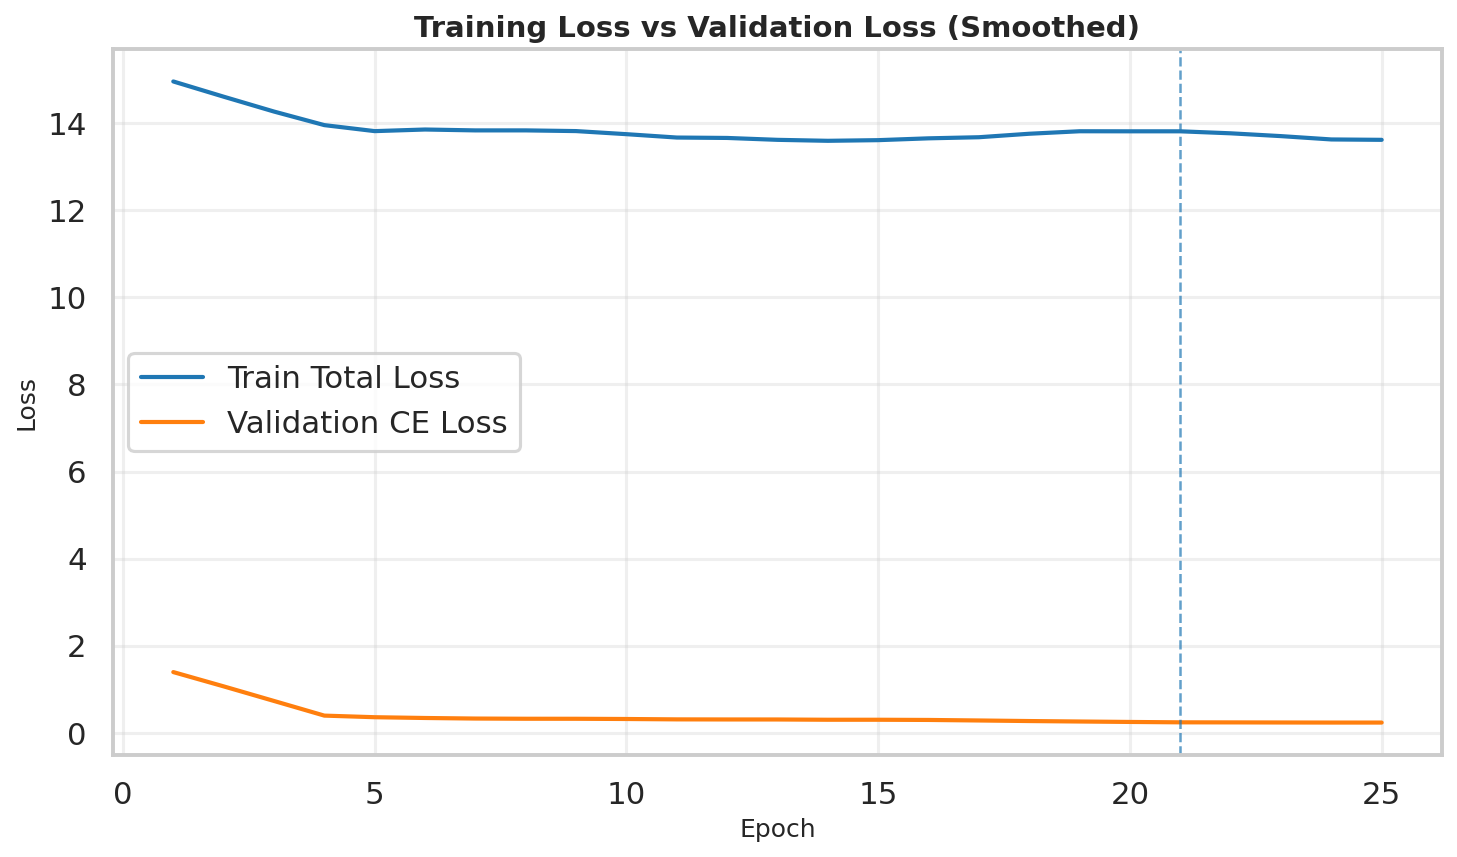

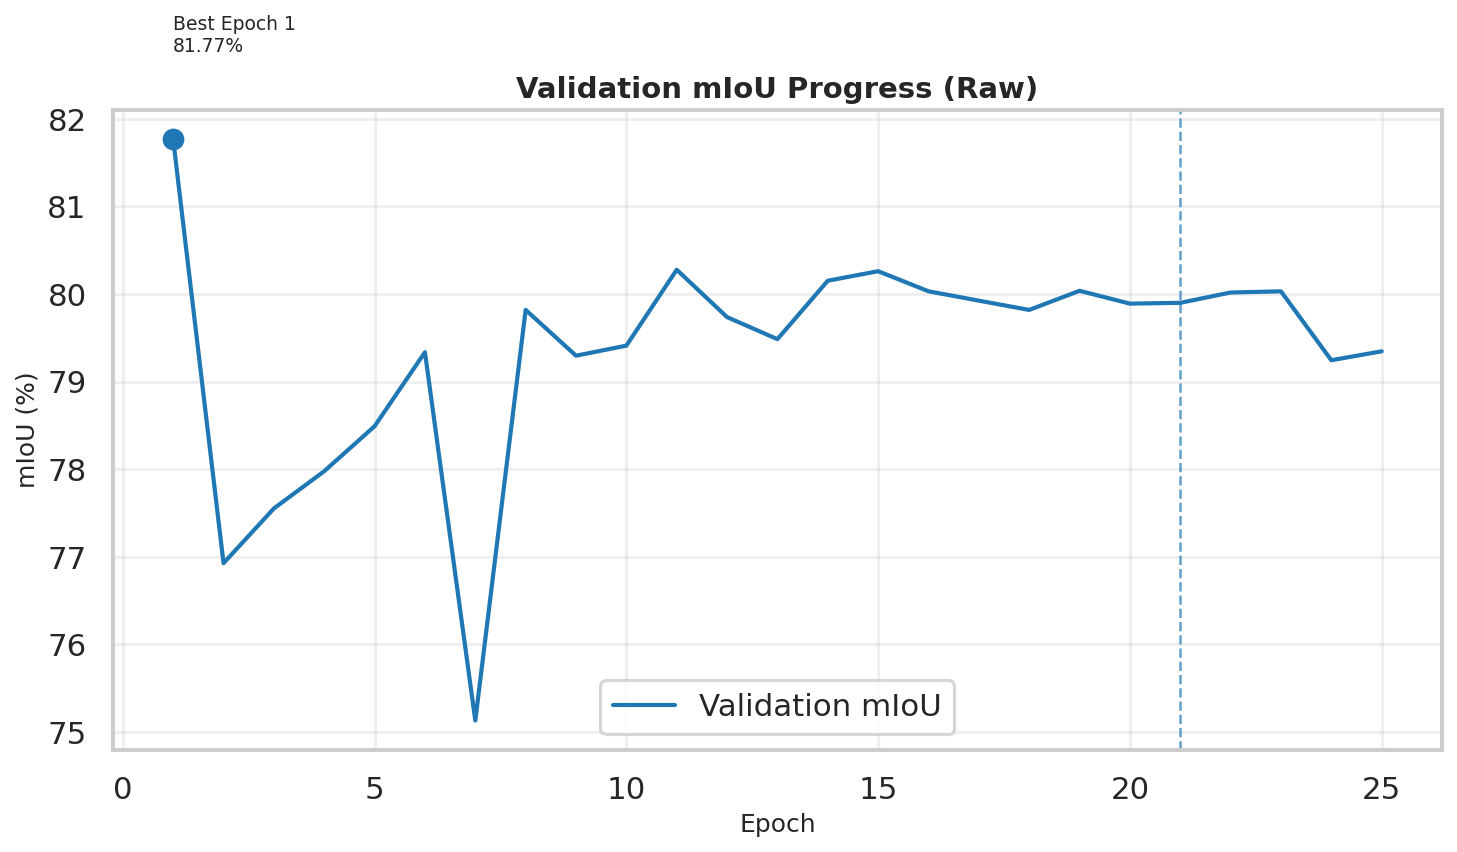

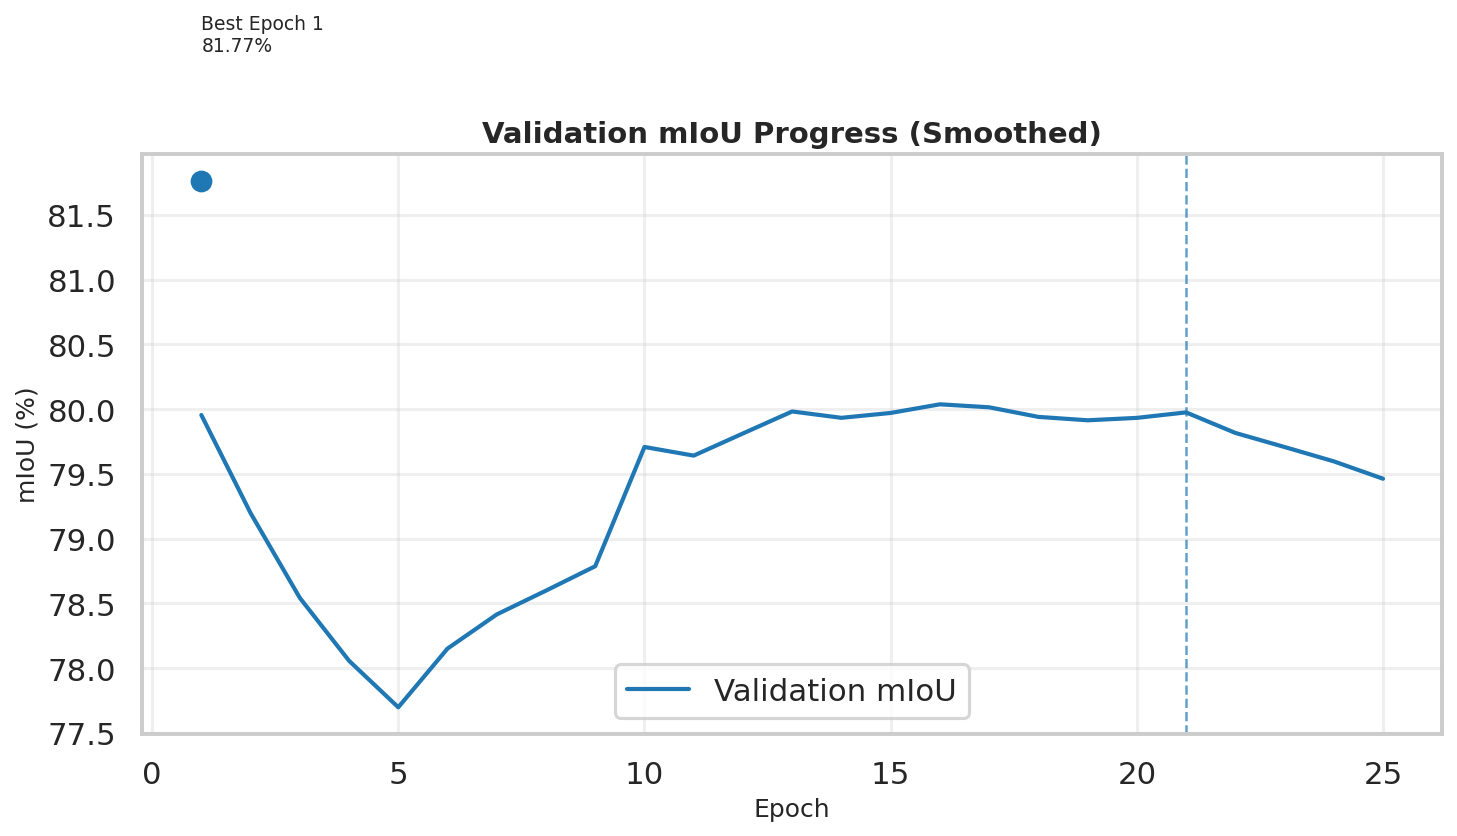

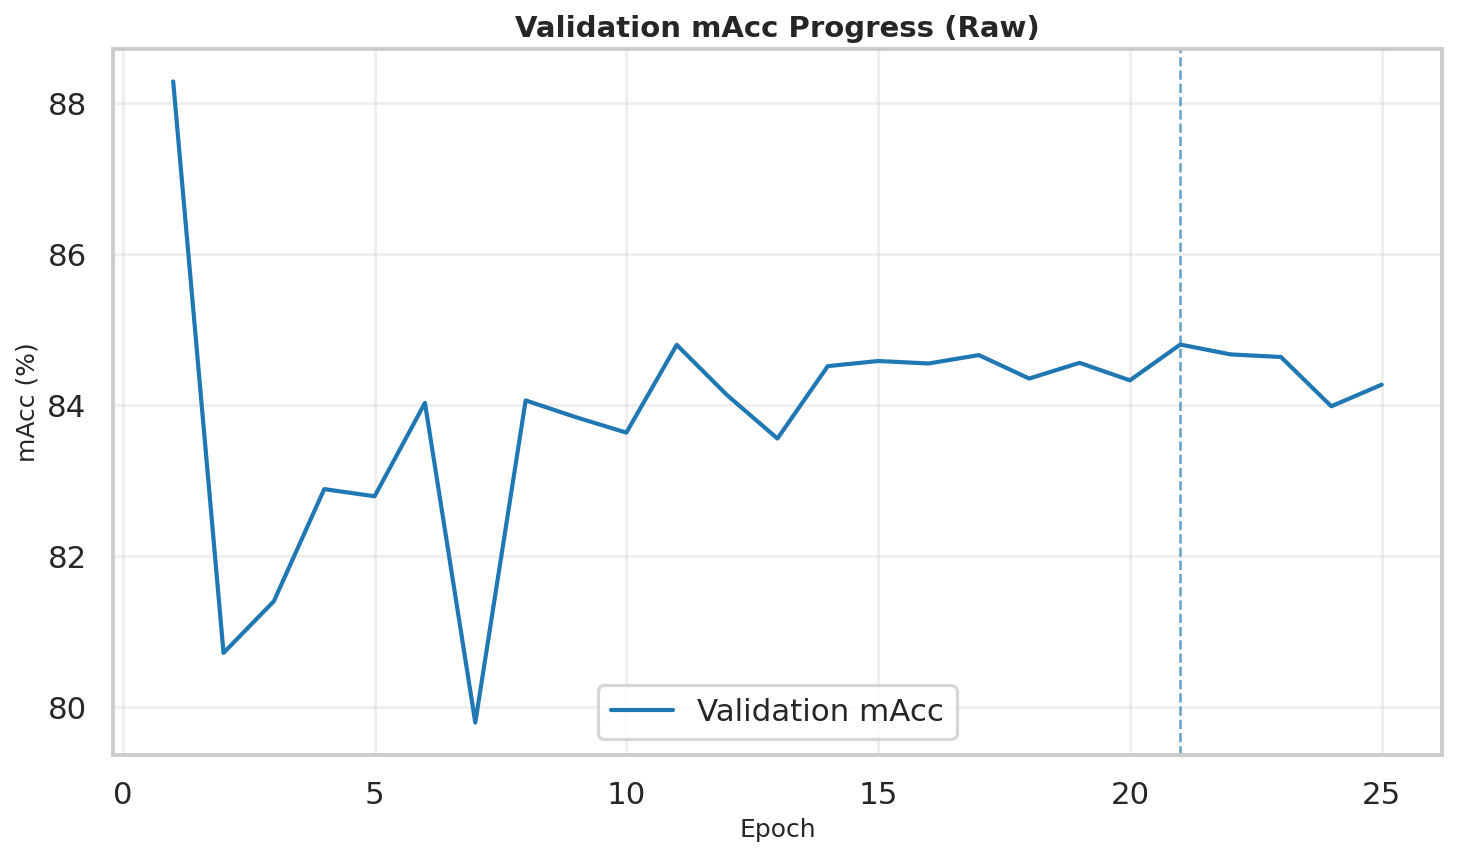

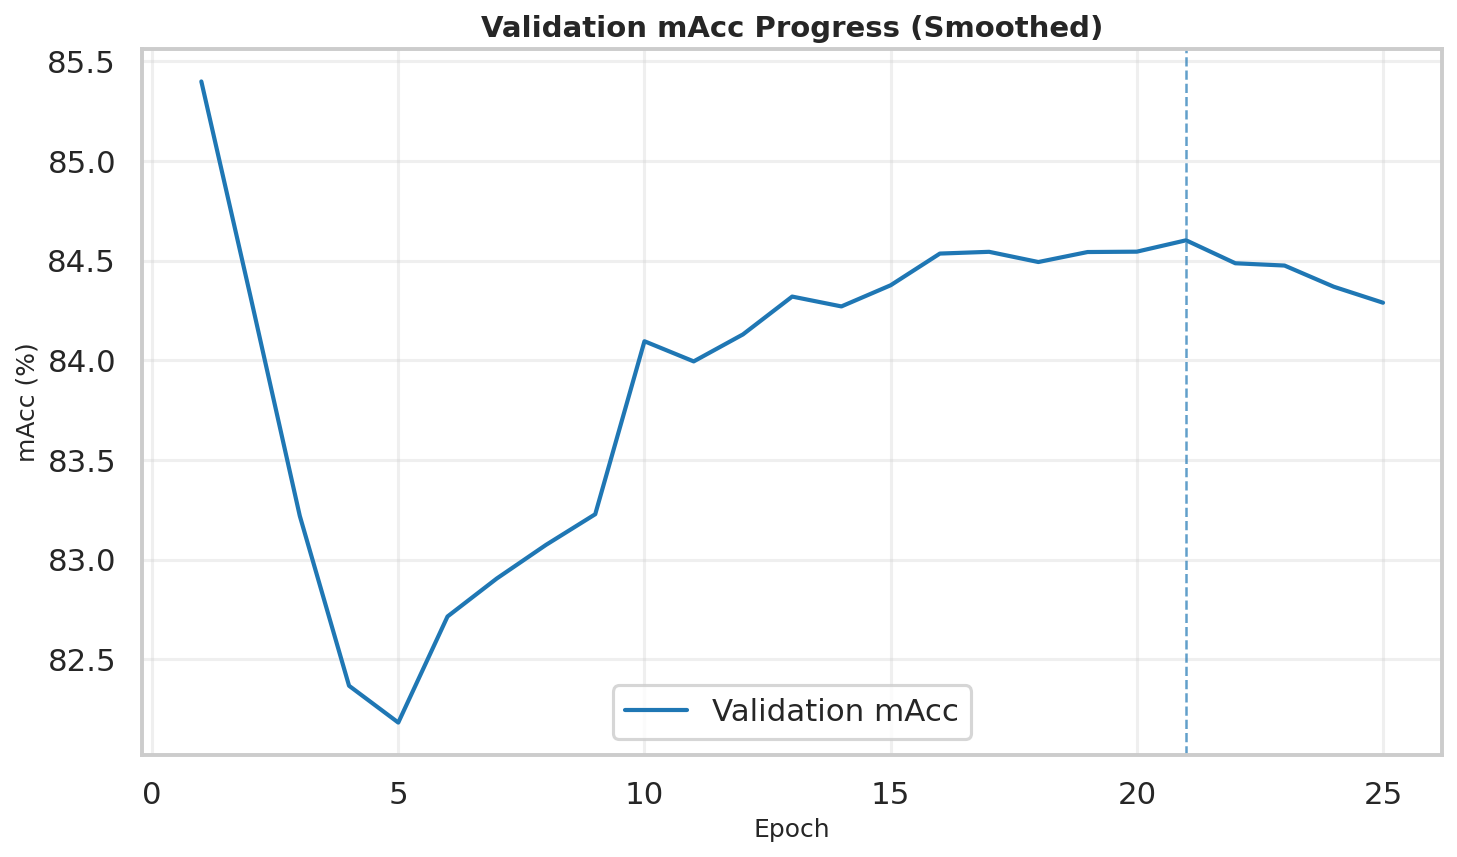

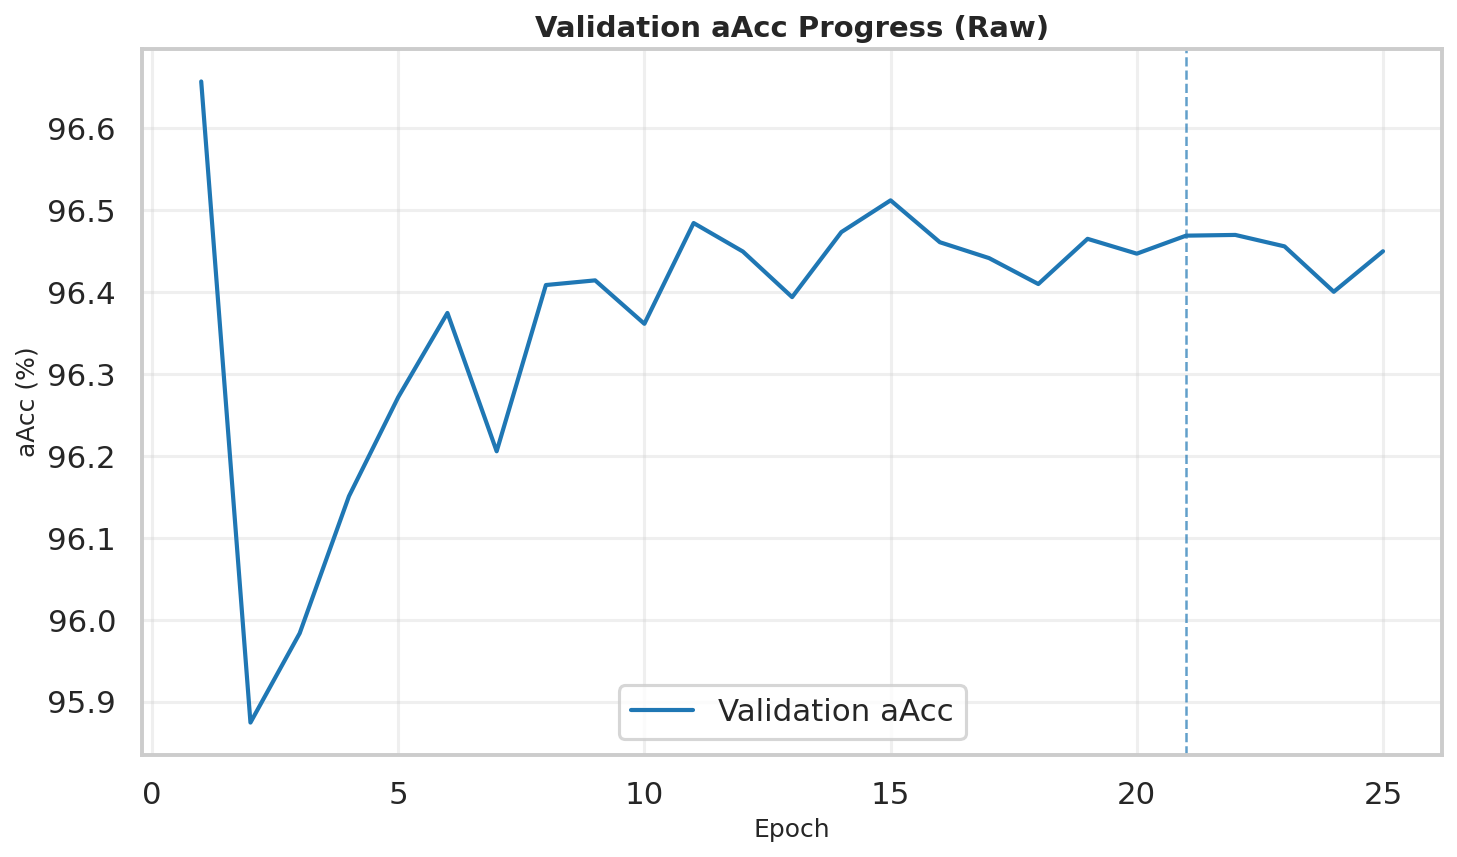

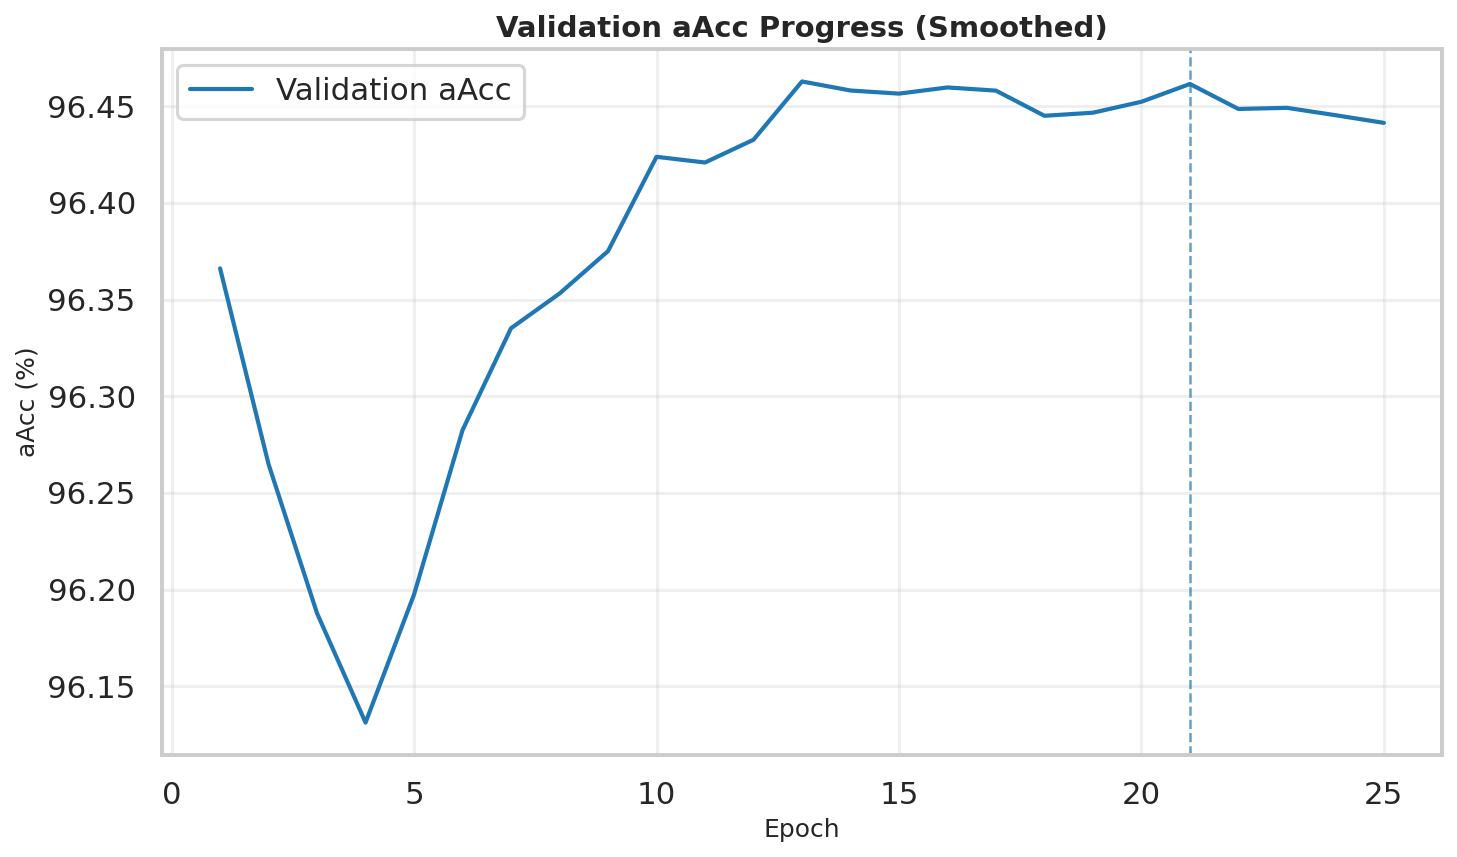

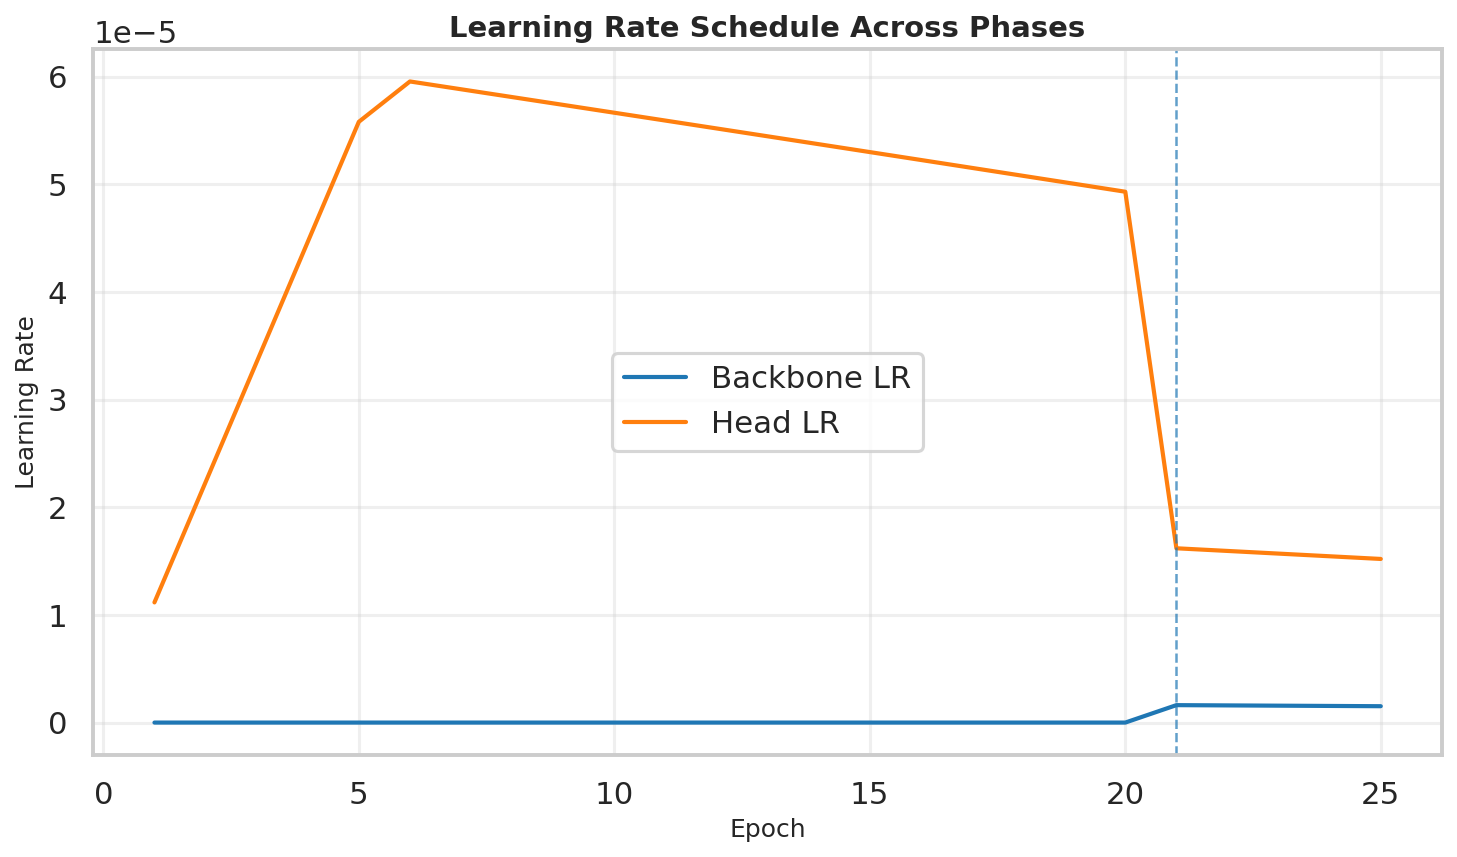

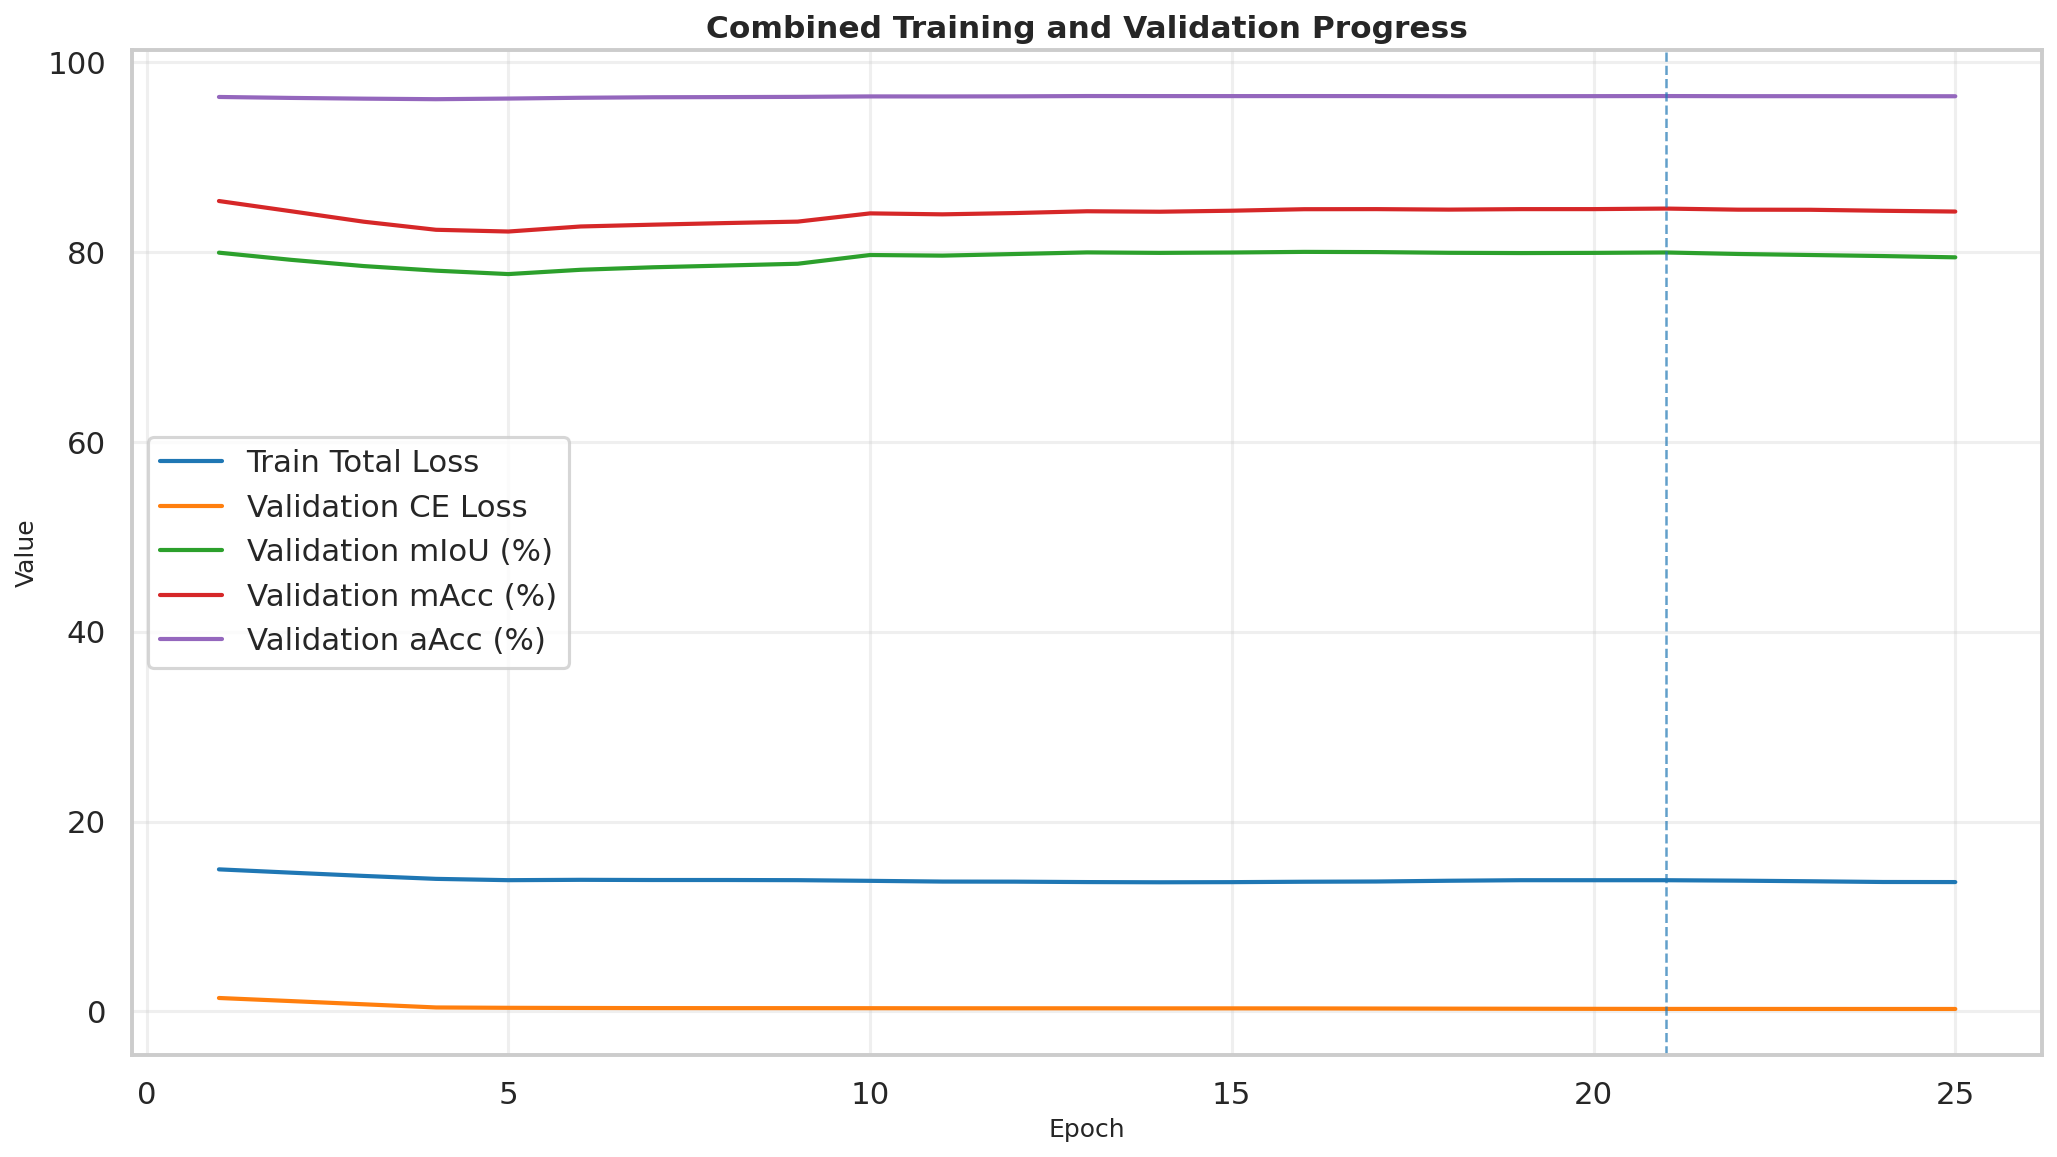

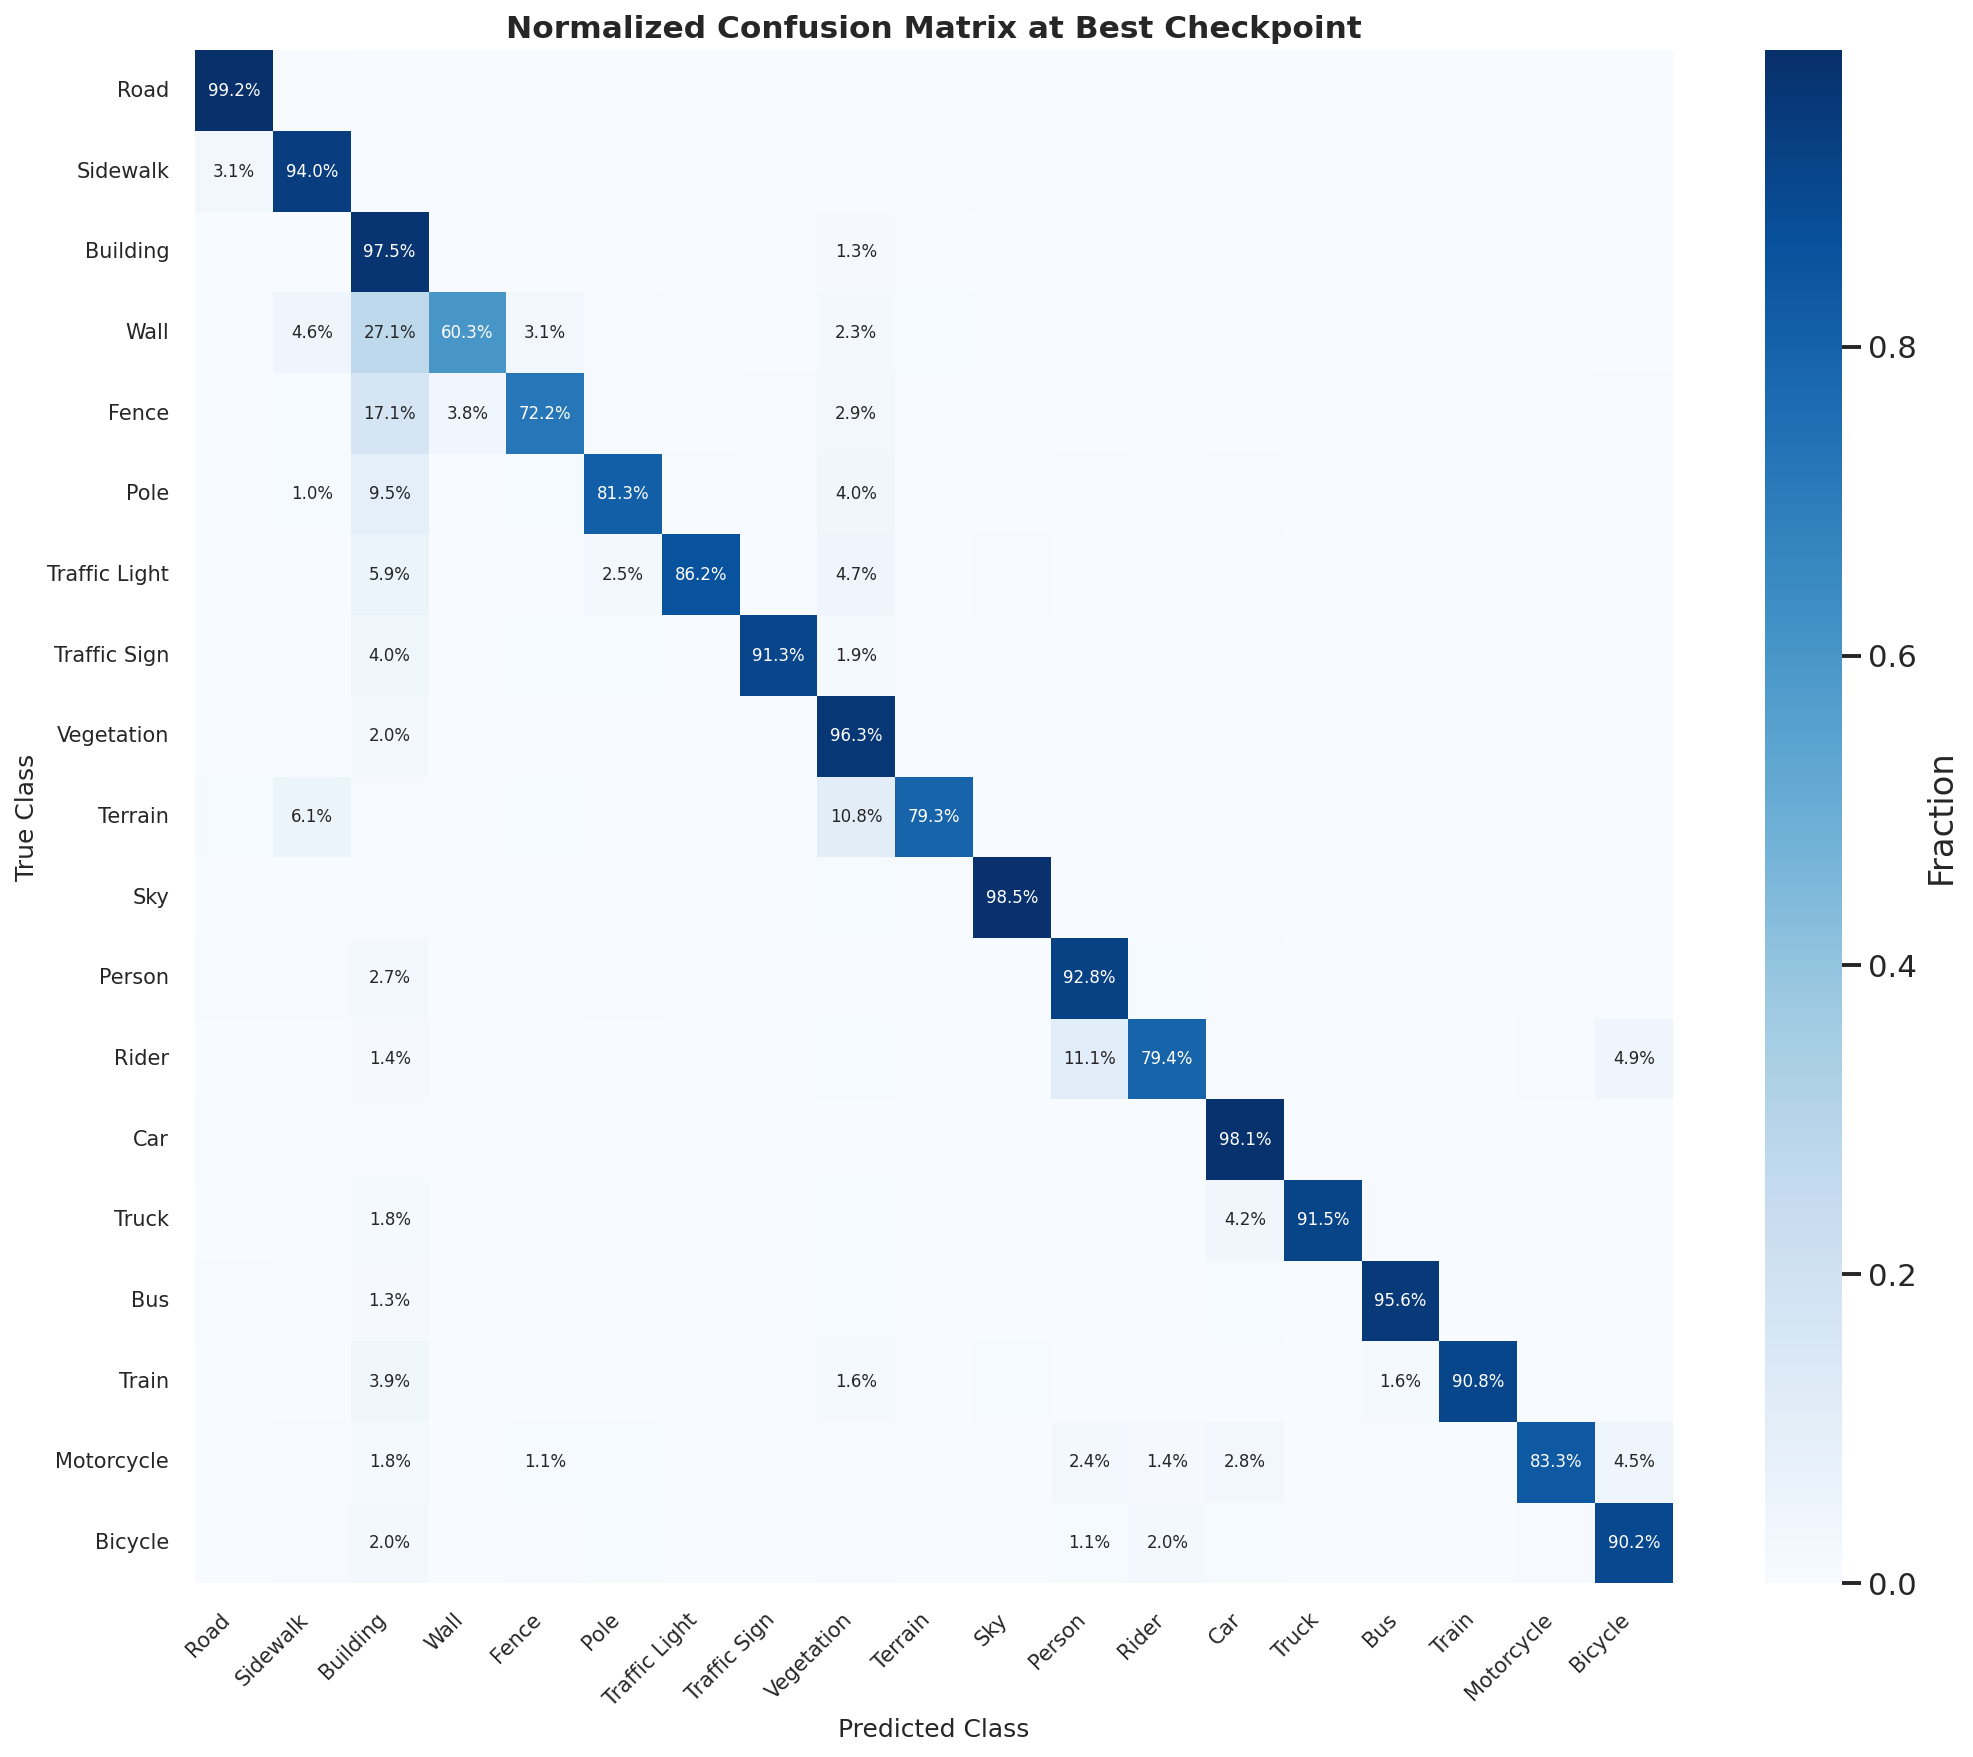


FINAL TRAINING SUMMARY
Model Name                        : Mask2Former + Swin-Small
Total Parameters                  : 68,723,870 (68.72 M)
Trainable Parameters              : 67,236,380 (67.24 M)
Non-Trainable Parameters          : 1,487,490 (1.49 M)
--------------------------------------------------------------------------------
Total Epochs Completed            : 25
Best Epoch                        : 1
Total Training Time               : 6:59:43
Average Epoch Time                : 1007.32 sec
--------------------------------------------------------------------------------
Average Validation mIoU over Training: 79.35%
Average Validation mAcc over Training: 83.92%
Average Validation aAcc over Training: 96.38%
--------------------------------------------------------------------------------
Final Train Total Loss            : 13.624653
Final Train Native Loss           : 13.11549486689207
Final Train CE Loss               : 0.246112
Final Train Lovasz Loss           : 0.524488
Final 

In [8]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# For: Mask2Former + Swin-Small
# Includes average mIoU / mAcc / aAcc over complete training
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

BEST_METRICS = globals().get("BEST_METRICS", None)
BEST_CONF_MATRIX = globals().get("BEST_CONF_MATRIX", None)

# ------------------------------------------------------------
# CUSTOM FINAL EXPORT DIRECTORY
# ------------------------------------------------------------
FINAL_SAVE_DIR = "/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/Results_Export"
FINAL_SAVE_DIR = Path(FINAL_SAVE_DIR)
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Final export directory: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME
# ------------------------------------------------------------
df = pd.DataFrame({
    "Epoch": history["epoch"],
    "Phase": history["phase"],
    "Train_Total_Loss": history["train_total_loss"],
    "Train_Native_Loss": history["train_native_loss"] if "train_native_loss" in history else [None] * len(history["epoch"]),
    "Train_CE_Loss": history["train_ce_loss"],
    "Train_Lovasz_Loss": history["train_lovasz_loss"],
    "Val_CE_Loss": history["val_ce_loss"],
    "Val_mIoU": history["val_miou"],
    "Val_mAcc": history["val_macc"],
    "Val_aAcc": history["val_aacc"],
    "LR_Backbone": history["backbone_lr"],
    "LR_Head": history["head_lr"],
    "Epoch_Time_sec": history["epoch_time_sec"],
})

# Add convenience percentage columns
df["Epoch_Time_min"] = df["Epoch_Time_sec"] / 60.0
df["Val_mIoU_pct"] = df["Val_mIoU"] * 100.0
df["Val_mAcc_pct"] = df["Val_mAcc"] * 100.0
df["Val_aAcc_pct"] = df["Val_aAcc"] * 100.0

# ------------------------------------------------------------
# BEST / FINAL / AVERAGE METRICS
# ------------------------------------------------------------
best_epoch = best_record.get("best_epoch", -1)
best_miou = best_record.get("best_miou", -1.0)
best_macc = best_record.get("best_macc", -1.0)
best_aacc = best_record.get("best_aacc", -1.0)

final_epoch = int(df["Epoch"].iloc[-1])
final_train_total_loss = float(df["Train_Total_Loss"].iloc[-1])
final_train_native_loss = float(df["Train_Native_Loss"].iloc[-1]) if pd.notna(df["Train_Native_Loss"].iloc[-1]) else None
final_train_ce_loss = float(df["Train_CE_Loss"].iloc[-1])
final_train_lovasz_loss = float(df["Train_Lovasz_Loss"].iloc[-1])
final_val_ce_loss = float(df["Val_CE_Loss"].iloc[-1])
final_val_miou = float(df["Val_mIoU"].iloc[-1])
final_val_macc = float(df["Val_mAcc"].iloc[-1])
final_val_aacc = float(df["Val_aAcc"].iloc[-1])

# Average over complete training
avg_val_miou = float(df["Val_mIoU"].mean())
avg_val_macc = float(df["Val_mAcc"].mean())
avg_val_aacc = float(df["Val_aAcc"].mean())

total_training_time_sec = float(df["Epoch_Time_sec"].sum())
total_training_time_str = str(timedelta(seconds=int(total_training_time_sec)))

# ------------------------------------------------------------
# PARAMETER COUNTS
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

param_summary = {
    "Model_Name": "Mask2Former + Swin-Small",
    "Total_Parameters": total_params,
    "Trainable_Parameters": trainable_params,
    "Non_Trainable_Parameters": non_trainable_params,
    "Total_Parameters_M": total_params / 1e6,
    "Trainable_Parameters_M": trainable_params / 1e6,
    "Non_Trainable_Parameters_M": non_trainable_params / 1e6,
}

# ------------------------------------------------------------
# CLASS-WISE TABLE
# ------------------------------------------------------------
class_wise_df = pd.DataFrame(columns=["Class_Name", "IoU_pct", "Accuracy_pct"])

if BEST_METRICS is not None:
    class_wise_rows = []
    for i, class_name in enumerate(CLASS_NAMES):
        class_wise_rows.append({
            "Class_Name": class_name,
            "IoU_pct": float(BEST_METRICS["iou_per_class"][i] * 100.0),
            "Accuracy_pct": float(BEST_METRICS["acc_per_class"][i] * 100.0)
        })
    class_wise_df = pd.DataFrame(class_wise_rows)

# ------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------
summary_rows = [
    {"Metric": "Best Epoch", "Value": best_epoch},
    {"Metric": "Best Validation mIoU (%)", "Value": best_miou * 100.0},
    {"Metric": "Best Validation mAcc (%)", "Value": best_macc * 100.0},
    {"Metric": "Best Validation aAcc (%)", "Value": best_aacc * 100.0},

    {"Metric": "Average Validation mIoU over Training (%)", "Value": avg_val_miou * 100.0},
    {"Metric": "Average Validation mAcc over Training (%)", "Value": avg_val_macc * 100.0},
    {"Metric": "Average Validation aAcc over Training (%)", "Value": avg_val_aacc * 100.0},

    {"Metric": "Final Epoch", "Value": final_epoch},
    {"Metric": "Final Train Total Loss", "Value": final_train_total_loss},
    {"Metric": "Final Train Native Loss", "Value": final_train_native_loss if final_train_native_loss is not None else "N/A"},
    {"Metric": "Final Train CE Loss", "Value": final_train_ce_loss},
    {"Metric": "Final Train Lovasz Loss", "Value": final_train_lovasz_loss},
    {"Metric": "Final Validation CE Loss", "Value": final_val_ce_loss},
    {"Metric": "Final Validation mIoU (%)", "Value": final_val_miou * 100.0},
    {"Metric": "Final Validation mAcc (%)", "Value": final_val_macc * 100.0},
    {"Metric": "Final Validation aAcc (%)", "Value": final_val_aacc * 100.0},
    {"Metric": "Total Training Time (sec)", "Value": total_training_time_sec},
    {"Metric": "Total Training Time", "Value": total_training_time_str},
    {"Metric": "Total Parameters", "Value": total_params},
    {"Metric": "Trainable Parameters", "Value": trainable_params},
    {"Metric": "Non-Trainable Parameters", "Value": non_trainable_params},
    {"Metric": "Total Parameters (M)", "Value": total_params / 1e6},
    {"Metric": "Trainable Parameters (M)", "Value": trainable_params / 1e6},
]
summary_df = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# SAVE CSV / EXCEL / JSON
# ------------------------------------------------------------
epoch_csv_path = FINAL_SAVE_DIR / "epoch_metrics.csv"
epoch_xlsx_path = FINAL_SAVE_DIR / "training_metrics_report.xlsx"
summary_csv_path = FINAL_SAVE_DIR / "final_summary.csv"
classwise_csv_path = FINAL_SAVE_DIR / "classwise_results.csv"
param_json_path = FINAL_SAVE_DIR / "parameter_summary.json"
finalresults_csv_path = FINAL_SAVE_DIR / "finalresults.csv"

df.to_csv(epoch_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)
class_wise_df.to_csv(classwise_csv_path, index=False)

finalresults_df = pd.DataFrame([
    {"Metric": "Average Mean IoU over Complete Training", "Value": f"{avg_val_miou * 100.0:.2f}%"},
    {"Metric": "Average Mean Class Accuracy over Complete Training", "Value": f"{avg_val_macc * 100.0:.2f}%"},
    {"Metric": "Average Pixel Accuracy over Complete Training", "Value": f"{avg_val_aacc * 100.0:.2f}%"},
    {"Metric": "Final Global Pixel Accuracy (aAcc)", "Value": f"{final_val_aacc * 100.0:.2f}%"},
    {"Metric": "Final Mean IoU (mIoU)", "Value": f"{final_val_miou * 100.0:.2f}%"},
    {"Metric": "Final Mean Class Accuracy (mAcc)", "Value": f"{final_val_macc * 100.0:.2f}%"},
    {"Metric": "Best Validation mIoU", "Value": f"{best_miou * 100.0:.2f}%"},
    {"Metric": "Best Epoch", "Value": f"{best_epoch}"}
])
finalresults_df.to_csv(finalresults_csv_path, index=False)

with open(param_json_path, "w") as f:
    json.dump(param_summary, f, indent=2)

with pd.ExcelWriter(epoch_xlsx_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Epoch_Metrics", index=False)
    summary_df.to_excel(writer, sheet_name="Final_Summary", index=False)
    class_wise_df.to_excel(writer, sheet_name="Class_Wise_Results", index=False)
    finalresults_df.to_excel(writer, sheet_name="Final_Results", index=False)

# ------------------------------------------------------------
# PLOTTING HELPERS
# ------------------------------------------------------------
sns.set_style("whitegrid")

def _smooth_series(values, window=5):
    values = np.asarray(values, dtype=np.float64)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    padded = np.pad(values, (window // 2, window // 2), mode="edge")
    smoothed = np.convolve(padded, kernel, mode="valid")
    return smoothed[:len(values)]

def save_plot(
    filename,
    title,
    ylabel,
    x,
    y1,
    y2=None,
    label1="Series 1",
    label2="Series 2",
    smooth=False,
    y_as_percent=False
):
    plt.figure(figsize=(10, 6))

    y1_plot = np.asarray(y1) * 100.0 if y_as_percent else np.asarray(y1)
    if smooth:
        y1_plot = _smooth_series(y1_plot)
    plt.plot(x, y1_plot, label=label1, linewidth=2)

    if y2 is not None:
        y2_plot = np.asarray(y2) * 100.0 if y_as_percent else np.asarray(y2)
        if smooth:
            y2_plot = _smooth_series(y2_plot)
        plt.plot(x, y2_plot, label=label2, linewidth=2)

    phase_changes = []
    prev_phase = history["phase"][0]
    for idx, ph in enumerate(history["phase"], start=1):
        if ph != prev_phase:
            phase_changes.append(idx)
            prev_phase = ph

    for phase_epoch in phase_changes:
        plt.axvline(x=phase_epoch, linestyle="--", linewidth=1.2, alpha=0.7)

    if "mIoU" in title and best_epoch != -1:
        best_y = best_miou * 100.0 if y_as_percent else best_miou
        plt.scatter([best_epoch], [best_y], s=80, zorder=5)
        plt.annotate(
            f"Best Epoch {best_epoch}\n{best_miou*100:.2f}%",
            xy=(best_epoch, best_y),
            xytext=(best_epoch, best_y + 1.0 if y_as_percent else best_y + 0.01),
            fontsize=9
        )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / filename, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
epochs = df["Epoch"].tolist()

save_plot(
    filename="loss_comparison_raw.png",
    title="Training Loss vs Validation Loss (Raw)",
    ylabel="Loss",
    x=epochs,
    y1=df["Train_Total_Loss"].tolist(),
    y2=df["Val_CE_Loss"].tolist(),
    label1="Train Total Loss",
    label2="Validation CE Loss",
    smooth=False,
    y_as_percent=False
)

save_plot(
    filename="loss_comparison_smoothed.png",
    title="Training Loss vs Validation Loss (Smoothed)",
    ylabel="Loss",
    x=epochs,
    y1=df["Train_Total_Loss"].tolist(),
    y2=df["Val_CE_Loss"].tolist(),
    label1="Train Total Loss",
    label2="Validation CE Loss",
    smooth=True,
    y_as_percent=False
)

save_plot(
    filename="miou_progress_raw.png",
    title="Validation mIoU Progress (Raw)",
    ylabel="mIoU (%)",
    x=epochs,
    y1=df["Val_mIoU"].tolist(),
    label1="Validation mIoU",
    smooth=False,
    y_as_percent=True
)

save_plot(
    filename="miou_progress_smoothed.png",
    title="Validation mIoU Progress (Smoothed)",
    ylabel="mIoU (%)",
    x=epochs,
    y1=df["Val_mIoU"].tolist(),
    label1="Validation mIoU",
    smooth=True,
    y_as_percent=True
)

save_plot(
    filename="macc_progress_raw.png",
    title="Validation mAcc Progress (Raw)",
    ylabel="mAcc (%)",
    x=epochs,
    y1=df["Val_mAcc"].tolist(),
    label1="Validation mAcc",
    smooth=False,
    y_as_percent=True
)

save_plot(
    filename="macc_progress_smoothed.png",
    title="Validation mAcc Progress (Smoothed)",
    ylabel="mAcc (%)",
    x=epochs,
    y1=df["Val_mAcc"].tolist(),
    label1="Validation mAcc",
    smooth=True,
    y_as_percent=True
)

save_plot(
    filename="aacc_progress_raw.png",
    title="Validation aAcc Progress (Raw)",
    ylabel="aAcc (%)",
    x=epochs,
    y1=df["Val_aAcc"].tolist(),
    label1="Validation aAcc",
    smooth=False,
    y_as_percent=True
)

save_plot(
    filename="aacc_progress_smoothed.png",
    title="Validation aAcc Progress (Smoothed)",
    ylabel="aAcc (%)",
    x=epochs,
    y1=df["Val_aAcc"].tolist(),
    label1="Validation aAcc",
    smooth=True,
    y_as_percent=True
)

save_plot(
    filename="learning_rate_progress.png",
    title="Learning Rate Schedule Across Phases",
    ylabel="Learning Rate",
    x=epochs,
    y1=df["LR_Backbone"].tolist(),
    y2=df["LR_Head"].tolist(),
    label1="Backbone LR",
    label2="Head LR",
    smooth=False,
    y_as_percent=False
)

plt.figure(figsize=(14, 8))
plt.plot(epochs, _smooth_series(df["Train_Total_Loss"].tolist()), label="Train Total Loss", linewidth=2)
plt.plot(epochs, _smooth_series(df["Val_CE_Loss"].tolist()), label="Validation CE Loss", linewidth=2)
plt.plot(epochs, _smooth_series((df["Val_mIoU"] * 100.0).tolist()), label="Validation mIoU (%)", linewidth=2)
plt.plot(epochs, _smooth_series((df["Val_mAcc"] * 100.0).tolist()), label="Validation mAcc (%)", linewidth=2)
plt.plot(epochs, _smooth_series((df["Val_aAcc"] * 100.0).tolist()), label="Validation aAcc (%)", linewidth=2)

phase_changes = []
prev_phase = history["phase"][0]
for idx, ph in enumerate(history["phase"], start=1):
    if ph != prev_phase:
        phase_changes.append(idx)
        prev_phase = ph
for phase_epoch in phase_changes:
    plt.axvline(x=phase_epoch, linestyle="--", linewidth=1.2, alpha=0.7)

plt.title("Combined Training and Validation Progress", fontsize=15, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FINAL_SAVE_DIR / "combined_metrics_progress.png", dpi=600, bbox_inches="tight")
plt.show()
plt.close()

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(14, 12))

    cm_normalized = BEST_CONF_MATRIX.astype(np.float64) / (
        BEST_CONF_MATRIX.sum(axis=1, keepdims=True) + 1e-10
    )

    annot_labels = np.empty_like(cm_normalized, dtype=object)
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            val = cm_normalized[i, j]
            annot_labels[i, j] = f"{val * 100:.1f}%" if val > 0.01 else ""

    sns.heatmap(
        cm_normalized,
        annot=annot_labels,
        fmt="",
        cmap="Blues",
        cbar_kws={"label": "Fraction"},
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot_kws={"size": 8}
    )

    plt.title("Normalized Confusion Matrix at Best Checkpoint", fontsize=15, fontweight="bold")
    plt.ylabel("True Class", fontsize=12)
    plt.xlabel("Predicted Class", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_annotated.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

# ------------------------------------------------------------
# FINAL PRINT SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("FINAL TRAINING SUMMARY")
print("=" * 80)

print(f"Model Name                        : Mask2Former + Swin-Small")
print(f"Total Parameters                  : {total_params:,} ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters              : {trainable_params:,} ({trainable_params/1e6:.2f} M)")
print(f"Non-Trainable Parameters          : {non_trainable_params:,} ({non_trainable_params/1e6:.2f} M)")
print("-" * 80)

print(f"Total Epochs Completed            : {final_epoch}")
print(f"Best Epoch                        : {best_epoch}")
print(f"Total Training Time               : {total_training_time_str}")
print(f"Average Epoch Time                : {df['Epoch_Time_sec'].mean():.2f} sec")
print("-" * 80)

print(f"Average Validation mIoU over Training: {avg_val_miou*100:.2f}%")
print(f"Average Validation mAcc over Training: {avg_val_macc*100:.2f}%")
print(f"Average Validation aAcc over Training: {avg_val_aacc*100:.2f}%")
print("-" * 80)

print(f"Final Train Total Loss            : {final_train_total_loss:.6f}")
print(f"Final Train Native Loss           : {final_train_native_loss if final_train_native_loss is not None else 'N/A'}")
print(f"Final Train CE Loss               : {final_train_ce_loss:.6f}")
print(f"Final Train Lovasz Loss           : {final_train_lovasz_loss:.6f}")
print(f"Final Validation CE Loss          : {final_val_ce_loss:.6f}")
print("-" * 80)

print(f"Best Validation mIoU              : {best_miou*100:.2f}%")
print(f"Best Validation mAcc              : {best_macc*100:.2f}%")
print(f"Best Validation aAcc              : {best_aacc*100:.2f}%")
print(f"Final Validation mIoU             : {final_val_miou*100:.2f}%")
print(f"Final Validation mAcc             : {final_val_macc*100:.2f}%")
print(f"Final Validation aAcc             : {final_val_aacc*100:.2f}%")
print("-" * 80)

print(f"Best Checkpoint Path              : {best_record.get('best_path', 'N/A')}")
print(f"Latest Checkpoint Path            : {Path(CHECKPOINT_DIR) / 'latest_checkpoint.pt'}")
print(f"Epoch Metrics CSV                 : {epoch_csv_path}")
print(f"Final Summary CSV                 : {summary_csv_path}")
print(f"Classwise Results CSV             : {classwise_csv_path}")
print(f"Final Results CSV                 : {finalresults_csv_path}")
print(f"Excel Report                      : {epoch_xlsx_path}")
print(f"Parameter Summary JSON            : {param_json_path}")
print(f"Export Directory                  : {FINAL_SAVE_DIR}")
print("=" * 80)

# ------------------------------------------------------------
# CLASS-WISE PRINT TABLE
# ------------------------------------------------------------
if len(class_wise_df) > 0:
    print("\nCLASS-WISE PERFORMANCE AT BEST CHECKPOINT")
    print("=" * 80)
    print(f"{'Class Name':<20} {'IoU (%)':>12} {'Accuracy (%)':>16}")
    print("-" * 80)
    for _, row in class_wise_df.iterrows():
        print(f"{row['Class_Name']:<20} {row['IoU_pct']:>12.2f} {row['Accuracy_pct']:>16.2f}")
    print("=" * 80)
else:
    print("\nNo class-wise metrics available in memory. Export completed without class-wise sheet.")

Filtered phase-annotated graph saved successfully to:
/home/hrusikesh-nishank/Pictures/swinsmall_Mask2Former_ce/Results_Export/combined_metrics_filtered_progress.png


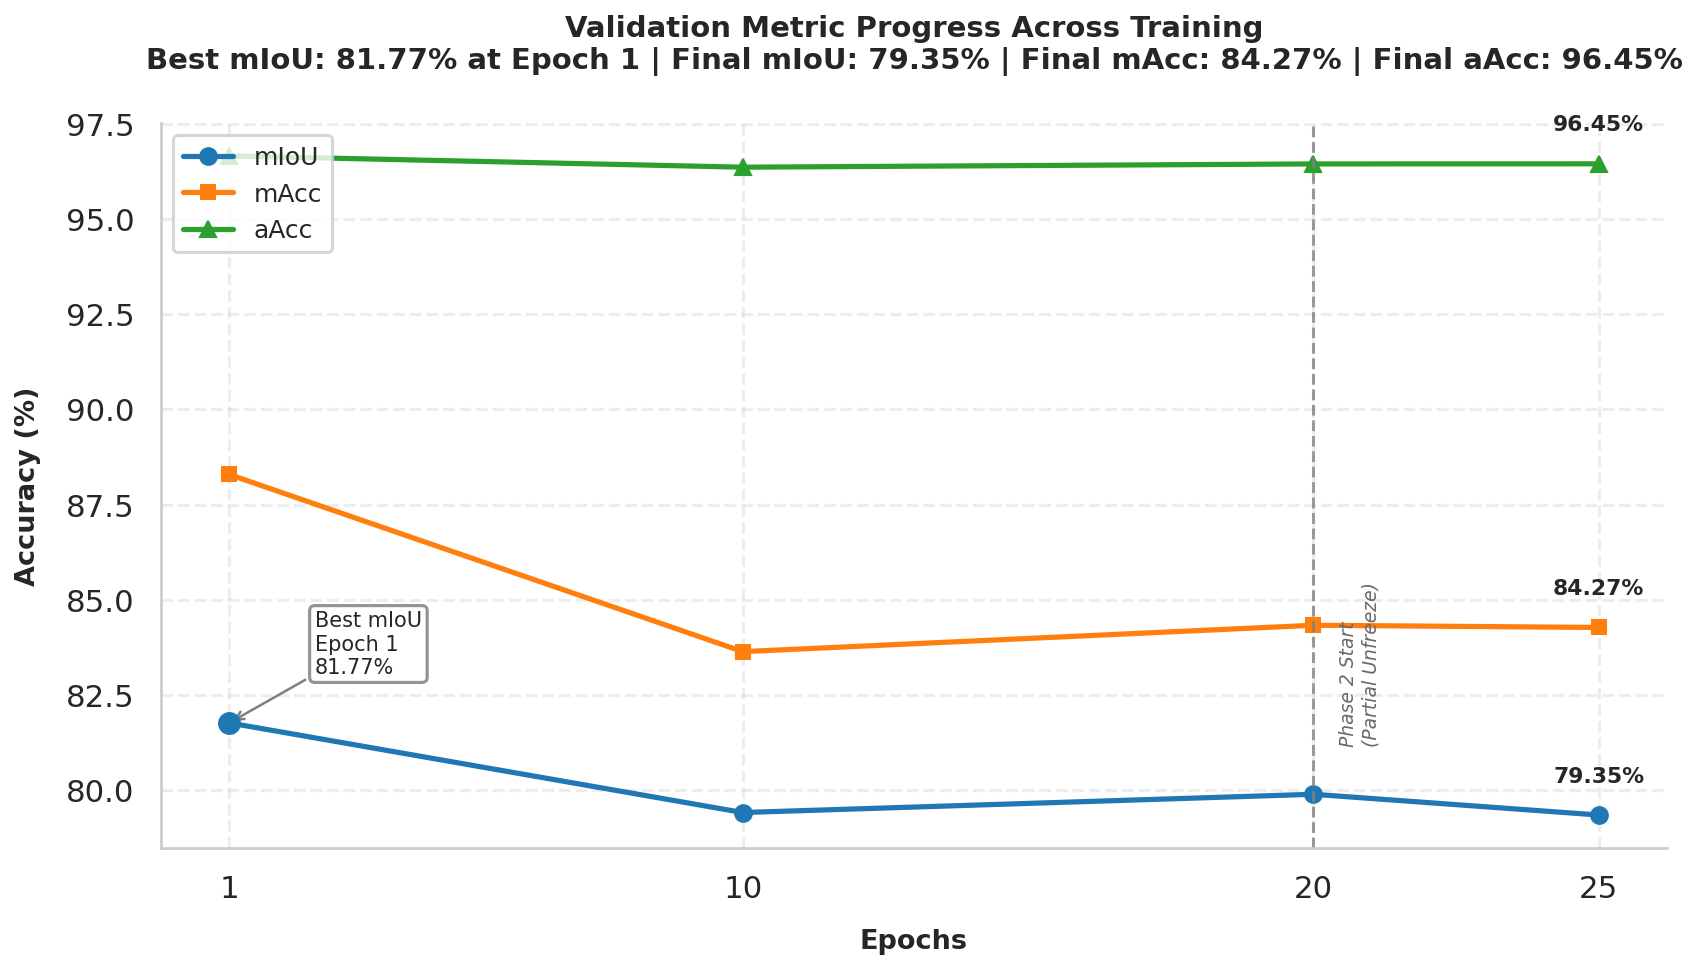

In [9]:
# --- STEP 7: PRESENTATION-READY MULTI-METRIC PROGRESS GRAPH (NO OVERLAP) ---

import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_globals = ["history", "FINAL_SAVE_DIR"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

if len(history["val_miou"]) == 0:
    raise ValueError("history['val_miou'] is empty. Run training before Step 7.")

phase1_end = globals().get("PHASE1_END_EPOCH", 15)
phase2_end = globals().get("PHASE2_END_EPOCH", 45)

# ------------------------------------------------------------
# PREPARE EPOCHS
# ------------------------------------------------------------
all_epochs = list(range(1, len(history["val_miou"]) + 1))

best_epoch = best_record.get("best_epoch", all_epochs[-1]) if "best_record" in globals() else all_epochs[-1]

filtered_epochs = sorted(set(
    [e for e in all_epochs if e == 1 or e % 10 == 0] +
    [all_epochs[-1], best_epoch]
))

indices = [e - 1 for e in filtered_epochs]

# ------------------------------------------------------------
# EXTRACT METRICS
# ------------------------------------------------------------
miou_scores = [history["val_miou"][i] * 100.0 for i in indices]
macc_scores = [history["val_macc"][i] * 100.0 for i in indices]
aacc_scores = [history["val_aacc"][i] * 100.0 for i in indices]

best_miou = max(history["val_miou"]) * 100.0
best_miou_epoch = history["val_miou"].index(max(history["val_miou"])) + 1

final_miou = history["val_miou"][-1] * 100.0
final_macc = history["val_macc"][-1] * 100.0
final_aacc = history["val_aacc"][-1] * 100.0
final_x = all_epochs[-1]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 7.5))

ax.plot(
    filtered_epochs, miou_scores,
    marker='o', linewidth=2.5, markersize=8,
    label='mIoU'
)
ax.plot(
    filtered_epochs, macc_scores,
    marker='s', linewidth=2.5, markersize=7,
    label='mAcc'
)
ax.plot(
    filtered_epochs, aacc_scores,
    marker='^', linewidth=2.5, markersize=8,
    label='aAcc'
)

# ------------------------------------------------------------
# AXIS LABELS
# ------------------------------------------------------------
ax.set_xlabel('Epochs', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xticks(filtered_epochs)

# ------------------------------------------------------------
# PHASE TRANSITION ANNOTATIONS
# ------------------------------------------------------------
y_min, y_max = ax.get_ylim()
offset_y = (y_max - y_min) * 0.04
phase_text_y = y_min + (y_max - y_min) * 0.14

if len(all_epochs) >= phase1_end + 1:
    ax.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.8, linewidth=1.4)
    ax.text(
        phase1_end + 0.45,
        phase_text_y,
        'Phase 2 Start\n(Partial Unfreeze)',
        rotation=90,
        va='bottom',
        ha='left',
        fontsize=9,
        color='dimgray',
        fontstyle='italic'
    )

if len(all_epochs) >= phase2_end + 1:
    ax.axvline(x=phase2_end, color='gray', linestyle='--', alpha=0.8, linewidth=1.4)
    ax.text(
        phase2_end + 0.45,
        phase_text_y,
        'Phase 3 Start\n(Gentle Full Fine-Tune)',
        rotation=90,
        va='bottom',
        ha='left',
        fontsize=9,
        color='dimgray',
        fontstyle='italic'
    )

# ------------------------------------------------------------
# BEST mIoU ANNOTATION
# ------------------------------------------------------------
ax.scatter(best_miou_epoch, best_miou, s=90, zorder=5)

# place annotation to the right or left depending on location
if best_miou_epoch <= (max(filtered_epochs) * 0.6):
    best_text_x = best_miou_epoch + 1.5
    best_ha = "left"
else:
    best_text_x = best_miou_epoch - 1.5
    best_ha = "right"

ax.annotate(
    f'Best mIoU\nEpoch {best_miou_epoch}\n{best_miou:.2f}%',
    xy=(best_miou_epoch, best_miou),
    xytext=(best_text_x, best_miou + 1.2),
    fontsize=10,
    ha=best_ha,
    va='bottom',
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2)
)

# ------------------------------------------------------------
# FINAL VALUE ANNOTATIONS
# ------------------------------------------------------------
ax.text(
    final_x,
    final_miou + offset_y,
    f'{final_miou:.2f}%',
    ha='center',
    va='bottom',
    fontsize=10.5,
    fontweight='bold'
)

ax.text(
    final_x,
    final_macc + offset_y,
    f'{final_macc:.2f}%',
    ha='center',
    va='bottom',
    fontsize=10.5,
    fontweight='bold'
)

ax.text(
    final_x,
    final_aacc + offset_y,
    f'{final_aacc:.2f}%',
    ha='center',
    va='bottom',
    fontsize=10.5,
    fontweight='bold'
)

# ------------------------------------------------------------
# STYLING
# ------------------------------------------------------------
ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.3)
ax.spines['left'].set_linewidth(1.3)

ax.grid(True, linestyle='--', alpha=0.35)

title_main = "Validation Metric Progress Across Training"
title_sub = f"Best mIoU: {best_miou:.2f}% at Epoch {best_miou_epoch} | Final mIoU: {final_miou:.2f}% | Final mAcc: {final_macc:.2f}% | Final aAcc: {final_aacc:.2f}%"

ax.set_title(
    title_main + "\n" + title_sub,
    fontsize=14,
    fontweight='bold',
    pad=26
)

# extra space at top so title never touches plot
plt.subplots_adjust(top=0.82)
plt.tight_layout(rect=[0, 0, 1, 0.90])

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
combined_graph_path = os.path.join(FINAL_SAVE_DIR, "combined_metrics_filtered_progress.png")
plt.savefig(combined_graph_path, dpi=600, bbox_inches='tight')
print(f"Filtered phase-annotated graph saved successfully to:\n{combined_graph_path}")

plt.show()
plt.close()